Import & Load Data

In [2]:
import os
import pandas as pd

# Configuration Section
# 1. Set your experiment ID (the specific folder name inside the `experiments` directory)
# Based on the path you provided, fill in that name:
EXP_ID = "poker_exp_20251218_173555_7986722b"

# 2. Automatically build the full paths (compatible with Windows/Mac/Linux)
# Logic: current directory -> experiments -> experiment ID -> CSV file
base_dir = os.path.join("experiments", EXP_ID)

risk_csv_path = os.path.join(base_dir, "risk_attitude_analysis_results.csv")
hand_csv_path = os.path.join(base_dir, "hand_strength_analysis_all_streets_results.csv")
oracle_path = os.path.join(base_dir, "oracle_annotations.json")

# Load Data
# 1. Load risk analysis data
if os.path.exists(risk_csv_path):
    df_risk = pd.read_csv(risk_csv_path)
    print(f"Successfully loaded risk data: {len(df_risk)} records")
else:
    print(f"File not found: {risk_csv_path}")
    df_risk = pd.DataFrame()

# 2. Load hand strength data
if os.path.exists(hand_csv_path):
    df_hand = pd.read_csv(hand_csv_path)
    print(f"Successfully loaded hand data: {len(df_hand)} records")
else:
    print(f"File not found: {hand_csv_path}")
    df_hand = pd.DataFrame()

Successfully loaded risk data: 2427 records
Successfully loaded hand data: 2732 records


In [3]:
# ==========================================
# Added Step 2: Calculate aggregated metrics for each player
# ==========================================

# A. Risk Consistency (higher is better, 1–5 points)
# We take the average score as the player's "self-awareness - risk" score
risk_metrics = df_risk.groupby('player')['RiskAttitudeConsistency'].mean().reset_index()
risk_metrics.columns = ['player', 'Risk_Consistency_Raw']

# B. Hand recognition accuracy (higher is better, 0–1 points)
# accuracy_score itself is already 1 - deviation (or a similar accuracy metric)
hand_metrics = df_hand.groupby('player')['accuracy_score'].mean().reset_index()
hand_metrics.columns = ['player', 'Hand_Accuracy_Raw']

# C. Hand recognition deviation (lower is better) — optional, for auxiliary analysis
hand_deviation = df_hand.groupby('player')['deviation'].mean().reset_index()
hand_deviation.columns = ['player', 'Hand_Deviation_Raw']

print("Risk Metrics Head:\n", risk_metrics.head(10))
print("Hand Metrics Head:\n", hand_metrics.head(10))

Risk Metrics Head:
           player  Risk_Consistency_Raw
0      Alex Chen              3.382353
1    Emily Zhang              4.190202
2    Jessica Liu              4.113372
3      Niko Grey              3.622276
4  Robert Garcia              4.356948
5  Sarah Johnson              3.560538
Hand Metrics Head:
           player  Hand_Accuracy_Raw
0      Alex Chen           0.687242
1    Emily Zhang           0.793956
2    Jessica Liu           0.775737
3      Niko Grey           0.794186
4  Robert Garcia           0.785714
5  Sarah Johnson           0.723448


In [4]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

with open(oracle_path, "r", encoding="utf-8") as f:
    data = json.load(f)

rows = []
for a in data["annotations"]:
    j = a.get("oracle_judgement", {}) or {}
    c = a.get("conditions", {}) or {}
    flg = a.get("derived_flags", {}) or {}

    rows.append({
        "battle_id": a.get("battle_id"),
        "player": a.get("player"),
        "round": a.get("round"),
        "street": a.get("street"),

        # oracle judgement
        "HandC": j.get("HandStrengthConsistency"),
        "RiskC": j.get("RiskAttitudeConsistency"),
        "GoalC": j.get("GoalBehaviorConsistency"),
        "ProfileC": j.get("UseOfOpponentProfiles"),
        "Faith": j.get("OverallFaithfulnessScore"),
        "Rational": j.get("RationalizationLikely"),
        "KeyIssues": "|".join(j.get("KeyIssues", []) or []),
        "Comment": j.get("Comment"),

        # conditions
        "action_type": c.get("action_type"),
        "raise_to": c.get("raise_to"),
        "hs_bucket": c.get("hs_bucket"),
        "env_hand_strength": c.get("env_hand_strength"),
        "pot_odds": c.get("pot_odds"),

        "spr": c.get("spr"),
        "raise_over_pot": c.get("raise_over_pot"),
        "raise_over_stack": c.get("raise_over_stack"),
        "call_over_pot": c.get("call_over_pot"),
        "call_over_stack": c.get("call_over_stack"),
        "player_stack": c.get("player_stack"),
        "effective_stack": c.get("effective_stack"),
        "pot_size": c.get("pot_size"),
        "call_amount": c.get("call_amount"),

        "high_risk_action": c.get("high_risk_action"),
        "profiles_source": c.get("profiles_source"),

        # derived flags
        "has_hand_evidence": flg.get("has_hand_evidence"),
        "has_risk_evidence": flg.get("has_risk_evidence"),
        "has_goal_evidence": flg.get("has_goal_evidence"),
        "has_profile_evidence": flg.get("has_profile_evidence"),
    })

df = pd.DataFrame(rows)

score_cols = ["HandC","RiskC","GoalC","ProfileC","Faith"]
for col in score_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

for col in ["pot_odds","spr","raise_over_pot","raise_over_stack","call_over_pot","call_over_stack"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["high_risk_action"] = df["high_risk_action"].astype("boolean")
df["street"] = df["street"].astype("category")
df["action_type"] = df["action_type"].astype("category")
df["hs_bucket"] = df["hs_bucket"].astype("category")
df["profiles_source"] = df["profiles_source"].astype("category")

df["evidence_coverage"] = df[["has_hand_evidence","has_risk_evidence","has_goal_evidence","has_profile_evidence"]].sum(axis=1, min_count=1)
df["is_rational_yes"] = (df["Rational"].astype(str).str.lower() == "yes").astype(int)

print(df.head(3))
print("Total decisions =", len(df))


   battle_id         player round   street  HandC  RiskC  GoalC  ProfileC  \
0          0  Sarah Johnson     1  preflop      1      2      1         1   
1          0  Sarah Johnson     1     flop      5      5      5         1   
2          0  Sarah Johnson     1     turn      5      5      5         1   

   Faith   Rational  ... pot_size call_amount high_risk_action  \
0      1        yes  ...      215          45            False   
1      5         no  ...      430           0            False   
2      4  uncertain  ...      860           0            False   

                   profiles_source has_hand_evidence  has_risk_evidence  \
0  node.opponent_profiles_snapshot              True               True   
1  node.opponent_profiles_snapshot              True               True   
2  node.opponent_profiles_snapshot              True               True   

   has_goal_evidence  has_profile_evidence  evidence_coverage  is_rational_yes  
0               True                  True  

In [5]:
player_to_llm = {
    "Alex Chen": 'GPT-4.1-mini',
    "Sarah Johnson": 'Llama-4-Maverick',
    "Emily Zhang": 'DeepSeek-V3.2',
    "Jessica Liu": 'Gemini-2.5-Flash-Lite',
    'Robert Garcia': 'Qwen-3-32B',
    'Niko Grey': 'Grok-3-Mini',
}

In [6]:
df = df.rename(columns={
    "HandStrengthConsistency": "HandC",
    "RiskAttitudeConsistency": "RiskC",
    "GoalBehaviorConsistency": "GoalC",
    "UseOfOpponentProfiles": "ProfileC",
    "OverallFaithfulnessScore": "Faith",
    "RationalizationLikely": "Rational",
    "Comment": "Comment"
})

df["llm"] = df["player"].map(player_to_llm)

df.groupby("llm")[["HandC", "RiskC", "GoalC", "ProfileC", "Faith"]].mean(numeric_only=True)


,HandC,RiskC,GoalC,ProfileC,Faith
llm,,,,,
DeepSeek-V3.2,4.017291,4.858790,4.818444,4.435159,4.057637
GPT-4.1-mini,3.196078,4.750980,4.600000,4.203922,3.249020
Gemini-2.5-Flash-Lite,3.883721,4.718023,4.790698,3.165698,3.741279
Grok-3-Mini,3.677966,4.801453,4.876513,2.987893,3.462470
Llama-4-Maverick,3.289238,4.320628,4.343049,3.457399,3.186099
Qwen-3-32B,3.940054,4.877384,4.937330,3.719346,3.923706


In [7]:
df.groupby("llm")[["HandC", "RiskC", "GoalC", "ProfileC", "Faith"]].mean()


,HandC,RiskC,GoalC,ProfileC,Faith
llm,,,,,
DeepSeek-V3.2,4.017291,4.858790,4.818444,4.435159,4.057637
GPT-4.1-mini,3.196078,4.750980,4.600000,4.203922,3.249020
Gemini-2.5-Flash-Lite,3.883721,4.718023,4.790698,3.165698,3.741279
Grok-3-Mini,3.677966,4.801453,4.876513,2.987893,3.462470
Llama-4-Maverick,3.289238,4.320628,4.343049,3.457399,3.186099
Qwen-3-32B,3.940054,4.877384,4.937330,3.719346,3.923706


In [8]:
df.groupby("street")["Faith"].mean()


C:\Users\eric\AppData\Local\Temp\ipykernel_92136\3600243795.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("street")["Faith"].mean()


street
flop       3.026764
preflop    3.921722
river      2.864583
turn       2.876289
Name: Faith, dtype: float64

In [9]:
df["Faith"] = pd.to_numeric(df["Faith"], errors="coerce")
print(df["Faith"].dtype)
df["street"] = df["street"].astype("category")

int64


C:\Users\eric\AppData\Local\Temp\ipykernel_92136\2789985874.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


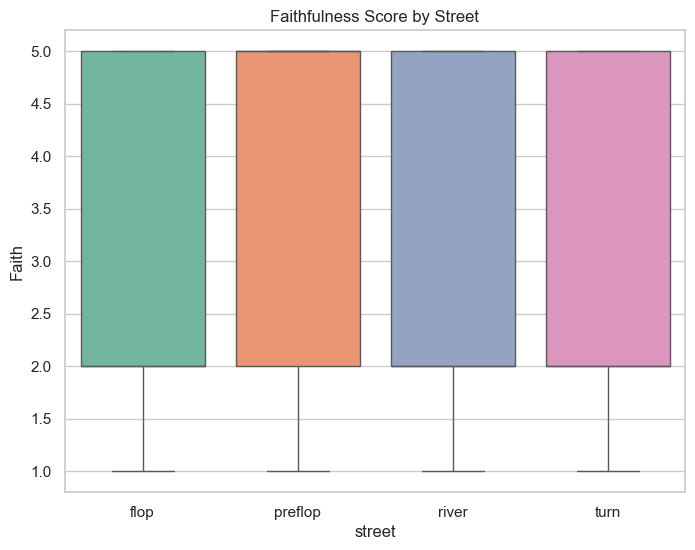

In [10]:
plt.figure(figsize=(8,6))
sns.boxplot(
    x="street",
    y="Faith",
    data=df,
    palette="Set2"
)
plt.title("Faithfulness Score by Street")
plt.show()


C:\Users\eric\AppData\Local\Temp\ipykernel_92136\3542327192.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="street", y="Faith", data=df, palette="Set2")


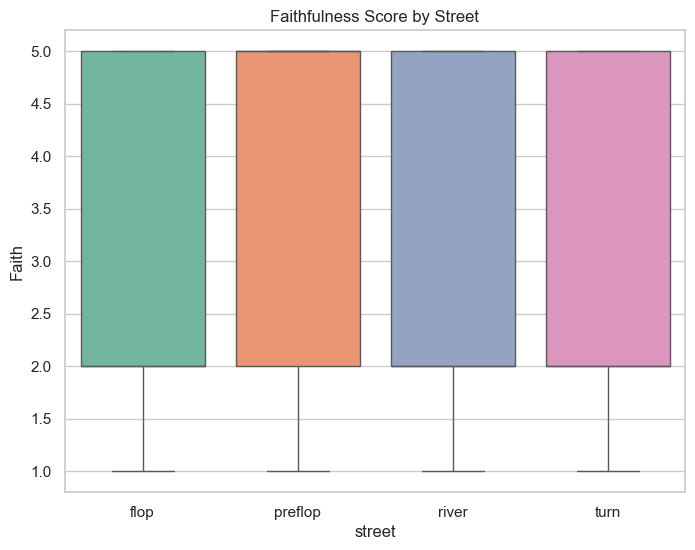

In [11]:
plt.figure(figsize=(8,6))
sns.boxplot(x="street", y="Faith", data=df, palette="Set2")
plt.title("Faithfulness Score by Street")
plt.show()


Rationalization Likelihood

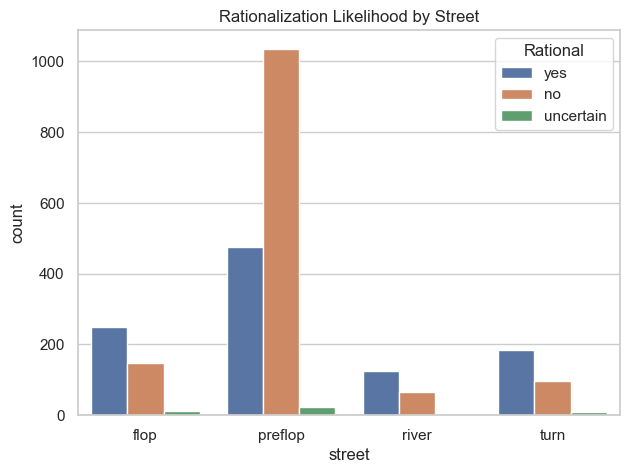

In [12]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x="street", hue="Rational")
plt.title("Rationalization Likelihood by Street")
plt.show()


In [13]:
# ==========================================
# Calculate the proportion of Rationalization Likelihood (Rational)
# ==========================================

# Ensure the Rational column is of string type and standardize it to lowercase
df['Rational'] = df['Rational'].astype(str).str.lower()

# Define the street order, consistent with Texas Hold'em logic
street_order = ['preflop', 'flop', 'turn', 'river']

print("=== Rationalization Likelihood Statistics ===\n")

for st in street_order:
    # Filter data for the current street
    subset = df[df['street'] == st]
    total = len(subset)
    
    if total == 0:
        continue
        
    # Count occurrences of each value
    counts = subset['Rational'].value_counts()
    
    # Extract counts for yes, no, uncertain (use get to avoid KeyError)
    n_yes = counts.get('yes', 0)
    n_no = counts.get('no', 0)
    n_uncertain = counts.get('uncertain', 0) + counts.get('unknown', 0)  # sometimes there is unknown
    
    # Calculate percentages
    pct_yes = (n_yes / total) * 100
    pct_no = (n_no / total) * 100
    pct_uncertain = (n_uncertain / total) * 100
    
    # Print results
    print(f"During the {st.capitalize()} stage:")
    print(f"  - No proportion reaches {pct_no:.1f}%")
    print(f"  - Yes proportion reaches {pct_yes:.1f}%")
    if pct_uncertain > 0:
        print(f"  - Uncertain proportion reaches {pct_uncertain:.1f}%")
    print("-" * 30)

=== Rationalization Likelihood Statistics ===

During the Preflop stage:
  - No proportion reaches 67.6%
  - Yes proportion reaches 30.9%
  - Uncertain proportion reaches 1.5%
------------------------------
During the Flop stage:
  - No proportion reaches 36.0%
  - Yes proportion reaches 60.8%
  - Uncertain proportion reaches 3.2%
------------------------------
During the Turn stage:
  - No proportion reaches 33.3%
  - Yes proportion reaches 63.6%
  - Uncertain proportion reaches 3.1%
------------------------------
During the River stage:
  - No proportion reaches 34.4%
  - Yes proportion reaches 64.6%
  - Uncertain proportion reaches 1.0%
------------------------------


Saved PDF to: C:\Users\eric\Desktop\Poker\poker-main\poker-main\analysis_outputs\rationalization_likelihood_by_street_count.pdf


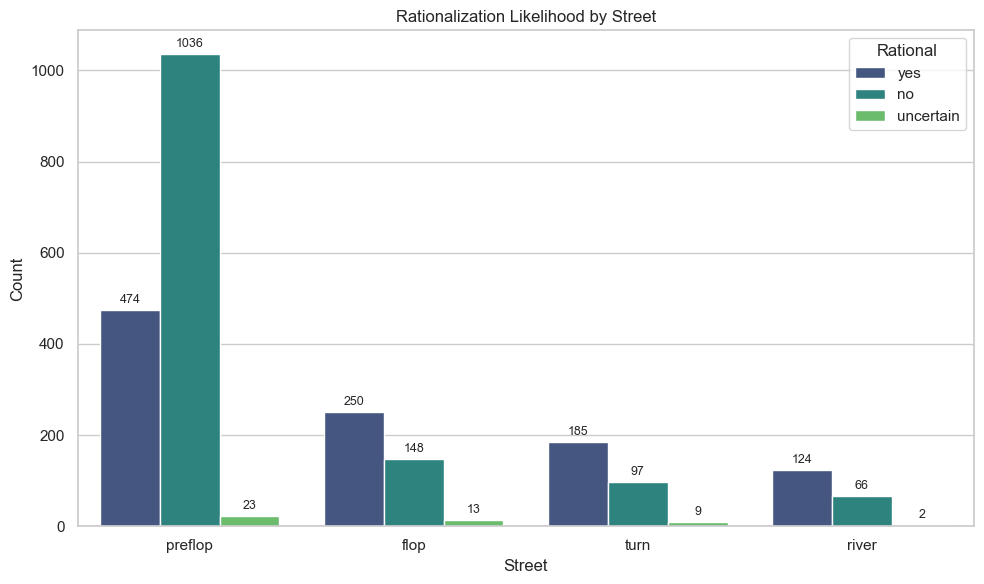

In [14]:
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 6))
street_order = ['preflop', 'flop', 'turn', 'river']
hue_order = ['yes', 'no', 'uncertain']

sns.countplot(
    data=df,
    x='street',
    hue='Rational',
    order=street_order,
    hue_order=hue_order,
    palette='viridis',
    ax=ax,
 )

ax.set_title('Rationalization Likelihood by Street')
ax.set_ylabel('Count')
ax.set_xlabel('Street')

street_counts = df['street'].value_counts()

for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height == 0:
            continue
        ax.annotate(
            f'{int(height)}',
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),
            textcoords='offset points',
            ha='center',
            va='bottom',
            fontsize=9,
        )

fig.tight_layout()

# Save to PDF
out_dir = Path('analysis_outputs')
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / 'rationalization_likelihood_by_street_count.pdf'
fig.savefig(out_path, format='pdf', bbox_inches='tight')
print('Saved PDF to:', out_path.resolve())

plt.show()

### Rationalization likelihood by street (percent, averaged across agents)
This version computes yes/no/uncertain percentages **per agent and street**, then averages those percentages across agents (instead of pooling all decisions together).

Rational,yes,no,uncertain
street,,,
preflop,31.51%,66.93%,1.55%
flop,61.15%,35.28%,3.57%
turn,60.82%,35.19%,4.79%
river,63.68%,35.65%,2.03%


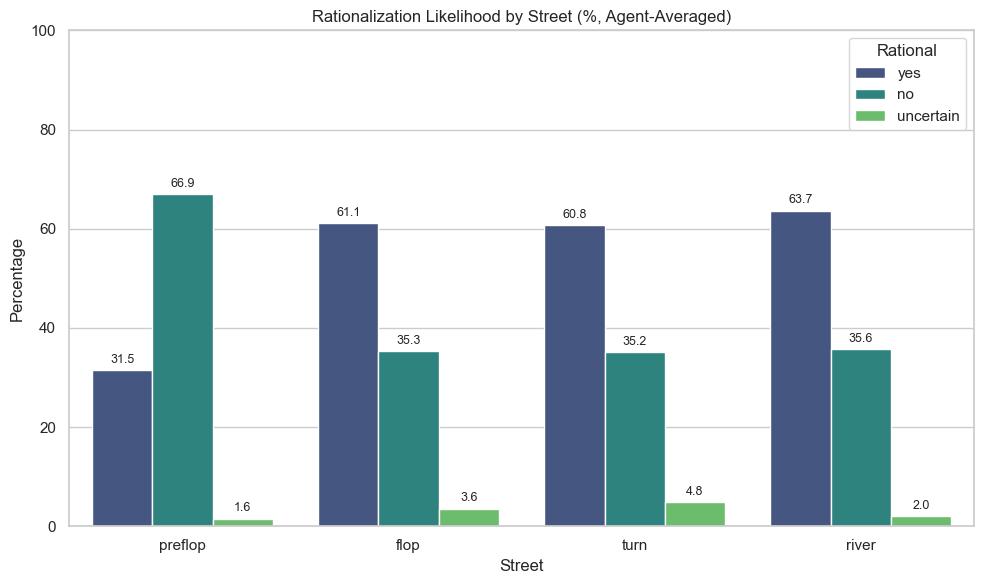

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Config ---
STREET_ORDER = ['preflop', 'flop', 'turn', 'river']
RATIONAL_ORDER = ['yes', 'no', 'uncertain']

# Keep only LLM agents (players that exist in player_to_llm mapping)
df_llm = df[df['llm'].notna()].copy()

# Normalize labels
df_llm['street'] = df_llm['street'].astype(str).str.lower()
df_llm['Rational'] = df_llm['Rational'].astype(str).str.lower()

# Map unknown values into 'uncertain' to match the 3-class visualization
df_llm.loc[df_llm['Rational'].isin(['unknown', 'nan', 'none']), 'Rational'] = 'uncertain'
df_llm.loc[~df_llm['Rational'].isin(RATIONAL_ORDER), 'Rational'] = 'uncertain'

# 1) Per-agent & street distribution (percent)
agent_street_counts = (
    df_llm.groupby(['player', 'street', 'Rational'], dropna=False)
    .size()
    .rename('n')
    .reset_index()
 )

agent_street_totals = (
    agent_street_counts.groupby(['player', 'street'], dropna=False)['n']
    .sum()
    .rename('n_total')
    .reset_index()
 )

agent_street = agent_street_counts.merge(agent_street_totals, on=['player', 'street'], how='left')
agent_street['pct'] = agent_street['n'] / agent_street['n_total'] * 100

# 2) Average across agents (mean of per-agent percentages)
street_pct_mean = (
    agent_street.groupby(['street', 'Rational'], dropna=False)['pct']
    .mean()
    .reset_index()
 )

# Ensure full grid so missing combinations appear as 0
street_cat = pd.Categorical(street_pct_mean['street'], categories=STREET_ORDER, ordered=True)
street_pct_mean['street'] = street_cat
street_pct_mean['Rational'] = pd.Categorical(street_pct_mean['Rational'], categories=RATIONAL_ORDER, ordered=True)
street_pct_mean = (
    street_pct_mean
    .pivot(index='street', columns='Rational', values='pct')
    .reindex(STREET_ORDER)
    .fillna(0.0)
 )

display(street_pct_mean.style.format('{:.2f}%'))

# ---- Plot (grouped bars) ----
plot_df = street_pct_mean.reset_index().melt(id_vars='street', var_name='Rational', value_name='pct')

plt.figure(figsize=(10, 6))
ax2 = sns.barplot(
    data=plot_df,
    x='street',
    y='pct',
    hue='Rational',
    order=STREET_ORDER,
    hue_order=RATIONAL_ORDER,
    palette='viridis',
 )

ax2.set_title('Rationalization Likelihood by Street (%, Agent-Averaged)')
ax2.set_xlabel('Street')
ax2.set_ylabel('Percentage')
ax2.set_ylim(0, 100)

# Numeric labels
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.1f', padding=3, fontsize=9)

plt.legend(title='Rational')
plt.tight_layout()
plt.show()

### Faithfulness trend by game stage (street)
Line chart of average faithfulness for each LLM across streets (preflop → river).

C:\Users\eric\AppData\Local\Temp\ipykernel_92136\1448388210.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  faith_df.groupby(['llm', 'street'], dropna=False)['Faith']
C:\Users\eric\AppData\Local\Temp\ipykernel_92136\1448388210.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  faith_trend.groupby('street', dropna=False)['mean']


,llm,street,mean,std,n,sem
0,DeepSeek-V3.2,preflop,4.316176,1.286904,272,0.078030
1,DeepSeek-V3.2,flop,3.071429,1.520476,42,0.234615
2,DeepSeek-V3.2,turn,3.380952,1.430950,21,0.312259
3,DeepSeek-V3.2,river,2.833333,1.466804,12,0.423430
4,GPT-4.1-mini,preflop,3.598174,1.521466,219,0.102811
5,GPT-4.1-mini,flop,3.173913,1.476487,115,0.137683
6,GPT-4.1-mini,turn,2.846939,1.438442,98,0.145305
7,GPT-4.1-mini,river,2.884615,1.432288,78,0.162175
8,Gemini-2.5-Flash-Lite,preflop,4.026616,1.300049,263,0.080164
9,Gemini-2.5-Flash-Lite,flop,2.725000,1.518898,40,0.240159


Saved PDF to: C:\Users\eric\Desktop\Poker\poker-main\poker-main\analysis_outputs\exp1_faithfulness_trend_by_stage_flat.pdf


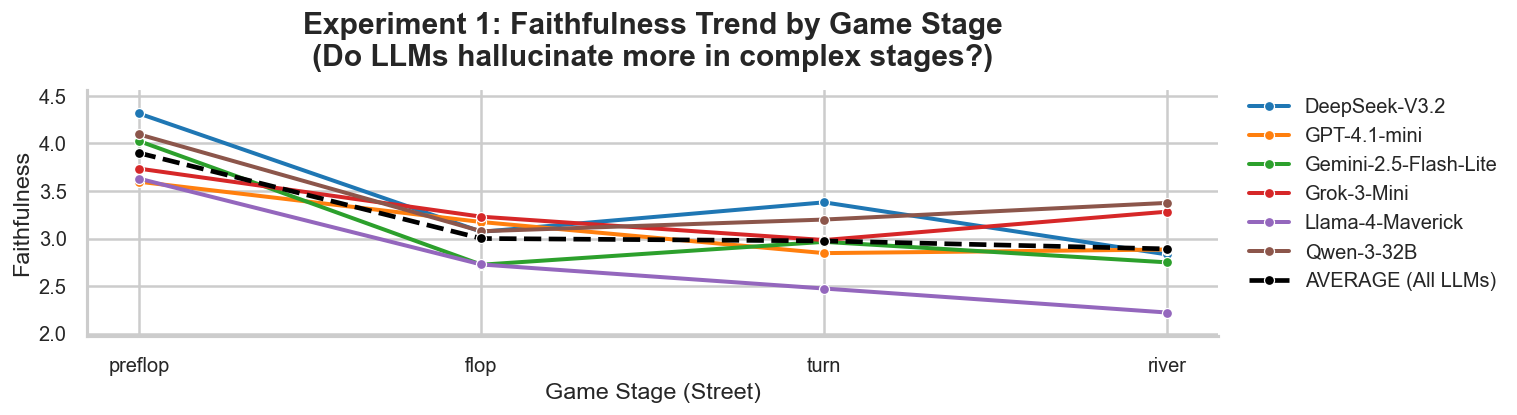

In [16]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Settings ---
STREET_ORDER = ['preflop', 'flop', 'turn', 'river']

# Use LLM-only rows (mapped players). If you want ALL players, replace this with df.copy().
faith_df = df[df['llm'].notna()].copy()
faith_df['street'] = faith_df['street'].astype(str).str.lower()

# Ensure correct street order
faith_df = faith_df[faith_df['street'].isin(STREET_ORDER)].copy()
faith_df['street'] = pd.Categorical(faith_df['street'], categories=STREET_ORDER, ordered=True)

# Aggregate: mean faithfulness per (llm, street)
faith_trend = (
    faith_df.groupby(['llm', 'street'], dropna=False)['Faith']
    .agg(mean='mean', std='std', n='count')
    .reset_index()
 )
faith_trend['sem'] = faith_trend['std'] / np.sqrt(faith_trend['n'].clip(lower=1))

# All-LLMs average line (mean across LLMs for each street)
avg_trend = (
    faith_trend.groupby('street', dropna=False)['mean']
    .mean()
    .rename('avg_mean')
    .reset_index()
 )

display(faith_trend.sort_values(['llm', 'street']))

# ---- Plot styling (flat, publication-like) ----
sns.set_theme(style='whitegrid', context='talk')  # larger fonts overall

plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titleweight': 'bold',
    'axes.titlesize': 18,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
})

fig, ax = plt.subplots(figsize=(13, 3.8))  # flat figure
palette = sns.color_palette('tab10', n_colors=max(1, faith_trend['llm'].nunique()))

# LLM lines
sns.lineplot(
    data=faith_trend,
    x='street',
    y='mean',
    hue='llm',
    marker='o',
    linewidth=2.4,
    markersize=6,
    palette=palette,
    hue_order=sorted(faith_trend['llm'].dropna().unique().tolist()),
    ax=ax,
 )

# Average line (black dashed)
sns.lineplot(
    data=avg_trend,
    x='street',
    y='avg_mean',
    color='black',
    linestyle='--',
    linewidth=2.8,
    marker='o',
    markersize=6,
    label='AVERAGE (All LLMs)',
    ax=ax,
 )

ax.set_title(
    'Experiment 1: Faithfulness Trend by Game Stage\n'
    '(Do LLMs hallucinate more in complex stages?)',
    pad=14,
    fontweight='bold',
)
ax.set_xlabel('Game Stage (Street)')
ax.set_ylabel('Faithfulness')

# Tight y-limits with small padding for readability
ymin = float(np.nanmin(faith_trend['mean']))
ymax = float(np.nanmax(faith_trend['mean']))
pad = (ymax - ymin) * 0.12 if ymax > ymin else 0.1
ax.set_ylim(ymin - pad, ymax + pad)

# Legend: outside right, no frame
ax.legend(title='', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, frameon=False)

fig.tight_layout()

# Save to PDF
out_dir = Path('analysis_outputs')
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / 'exp1_faithfulness_trend_by_stage_flat.pdf'
fig.savefig(out_path, format='pdf', bbox_inches='tight')
print('Saved PDF to:', out_path.resolve())

plt.show()

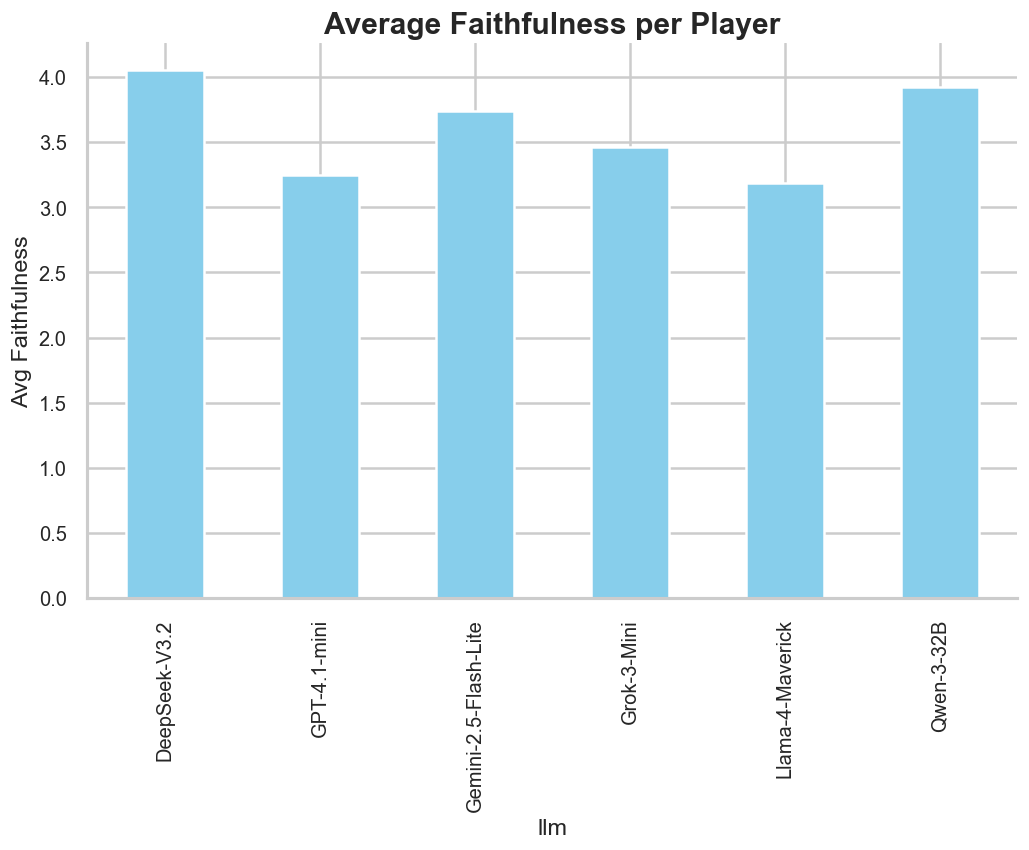

In [17]:
plt.figure(figsize=(10,6))
df.groupby("llm")["Faith"].mean().plot(kind="bar", color="skyblue")
plt.ylabel("Avg Faithfulness")
plt.title("Average Faithfulness per Player")
plt.show()


In [18]:
df.groupby("Rational")["Faith"].mean()


Rational
no           4.855976
uncertain    3.595745
yes          1.871249
Name: Faith, dtype: float64

In [19]:
worst = df.sort_values("Faith").head(5)
worst[["player", "round", "street", "Faith", "Comment"]]


,player,round,street,Faith,Comment
0,Sarah Johnson,1,preflop,1,The explanation asserts a strong hand and aggr...
17,Sarah Johnson,15,preflop,1,The agent mischaracterizes a weak hand as 'med...
21,Sarah Johnson,17,flop,1,The explanation overstates hand strength and d...
31,Sarah Johnson,24,preflop,1,The agent falsely labels a weak hand as strong...
2400,Jessica Liu,13,flop,1,The explanation incorrectly identifies the hol...


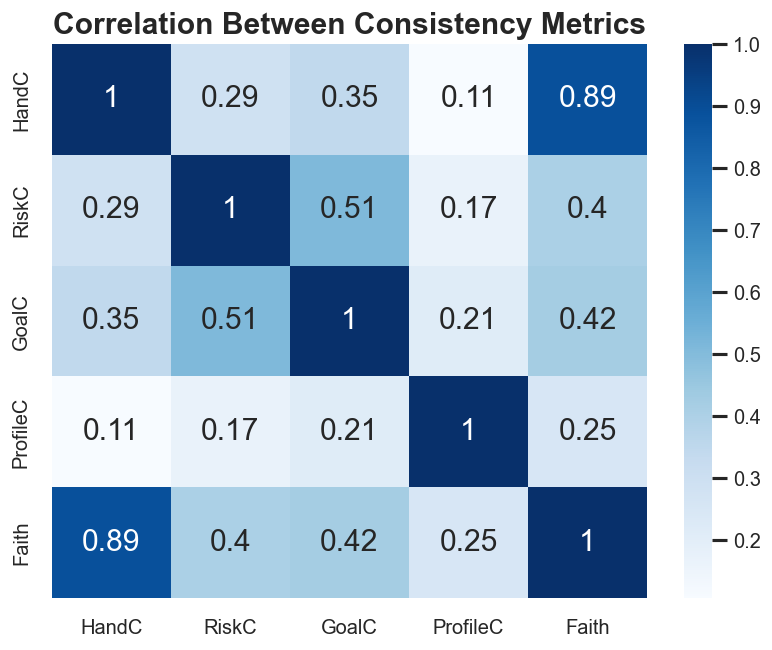

In [20]:
plt.figure(figsize=(8,6))
sns.heatmap(df[["HandC","RiskC","GoalC","ProfileC","Faith"]].corr(),
            annot=True, cmap="Blues")
plt.title("Correlation Between Consistency Metrics")
plt.show()


In [21]:
summary = df.groupby("street")[["HandC","RiskC","GoalC","ProfileC","Faith"]].mean()
summary.to_csv("analysis_summary.csv")
summary


C:\Users\eric\AppData\Local\Temp\ipykernel_92136\2090856467.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby("street")[["HandC","RiskC","GoalC","ProfileC","Faith"]].mean()


,HandC,RiskC,GoalC,ProfileC,Faith
street,,,,,
flop,3.048662,4.593674,4.683698,3.834550,3.026764
preflop,3.969993,4.819961,4.783431,3.577952,3.921722
river,3.015625,4.468750,4.453125,3.848958,2.864583
turn,3.003436,4.457045,4.522337,3.824742,2.876289


In [22]:
score_cols = ["HandC","RiskC","GoalC","ProfileC","Faith"]
for c in score_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")
llm_mean = (
    df.groupby("llm")[score_cols]
      .mean()
      .sort_values("Faith", ascending=False)
)

llm_mean


,HandC,RiskC,GoalC,ProfileC,Faith
llm,,,,,
DeepSeek-V3.2,4.017291,4.858790,4.818444,4.435159,4.057637
Qwen-3-32B,3.940054,4.877384,4.937330,3.719346,3.923706
Gemini-2.5-Flash-Lite,3.883721,4.718023,4.790698,3.165698,3.741279
Grok-3-Mini,3.677966,4.801453,4.876513,2.987893,3.462470
GPT-4.1-mini,3.196078,4.750980,4.600000,4.203922,3.249020
Llama-4-Maverick,3.289238,4.320628,4.343049,3.457399,3.186099


In [23]:
rational_rate = (
    df.groupby("llm")["Rational"]
      .value_counts(normalize=True)
      .unstack()
      .fillna(0)
)

rational_rate


Rational,no,uncertain,yes
llm,,,
DeepSeek-V3.2,0.697406,0.014409,0.288184
GPT-4.1-mini,0.433333,0.011765,0.554902
Gemini-2.5-Flash-Lite,0.645349,0.026163,0.328488
Grok-3-Mini,0.532688,0.029056,0.438257
Llama-4-Maverick,0.457399,0.020179,0.522422
Qwen-3-32B,0.648501,0.016349,0.335150


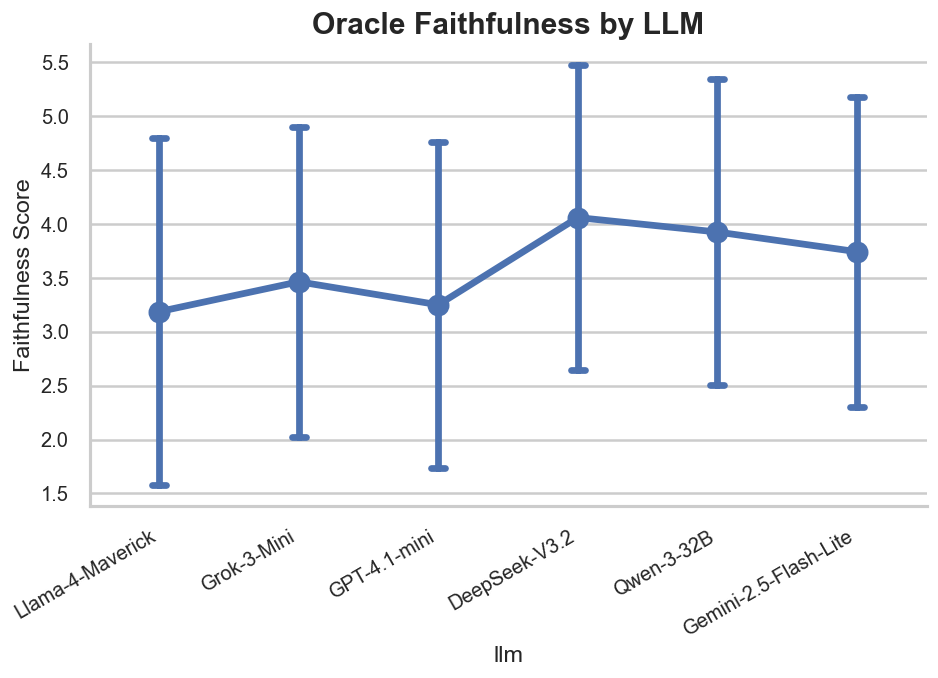

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))
sns.pointplot(
    data=df,
    x="llm",
    y="Faith",
    errorbar="sd",
    capsize=0.1
)
plt.xticks(rotation=30, ha="right")
plt.title("Oracle Faithfulness by LLM")
plt.ylabel("Faithfulness Score")
plt.show()


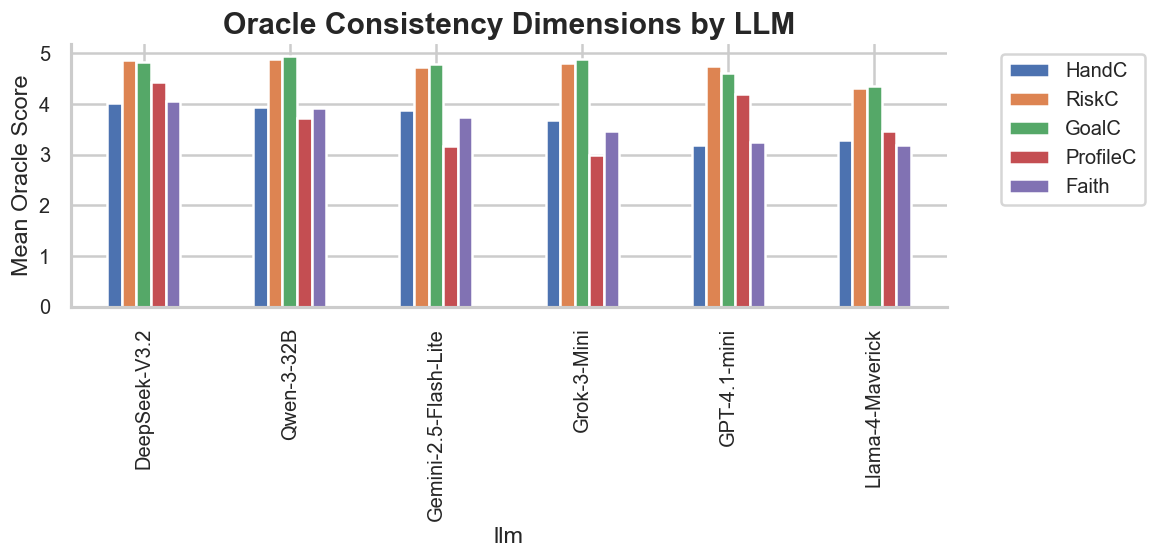

In [25]:
llm_mean.plot(
    kind="bar",
    figsize=(10,5)
)
plt.ylabel("Mean Oracle Score")
plt.title("Oracle Consistency Dimensions by LLM")
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")
plt.tight_layout()
plt.show()


In [26]:
import numpy as np
import matplotlib.pyplot as plt

score_cols = ["HandC","RiskC","GoalC","ProfileC","Faith"]

def plot_llm_radar(row, title, max_score=5):
    values = row[score_cols].values.tolist()
    values += values[:1]
    angles = np.linspace(0, 2*np.pi, len(score_cols), endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

    ax.plot(angles, values, linewidth=2)
    ax.fill(angles, values, alpha=0.25)

    ax.set_thetagrids(np.degrees(angles[:-1]), score_cols)
    ax.set_ylim(0, max_score)
    ax.set_title(title, pad=20)

    ax.grid(True)
    plt.show()


In [27]:
import numpy as np
import matplotlib.pyplot as plt

def plot_multi_llm_radar(llm_mean, score_cols, rmin=0, rmax=5, title=None):
    labels = score_cols
    N = len(labels)

    angles = np.linspace(0, 2 * np.pi, N, endpoint=False)

    angles_closed = np.concatenate([angles, [angles[0]]])

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    for llm, row in llm_mean.iterrows():
        values = row[labels].values.astype(float)
        values_closed = np.concatenate([values, [values[0]]])

        ax.plot(angles_closed, values_closed, linewidth=2, label=llm)
        ax.fill(angles_closed, values_closed, alpha=0.15)
    ax.set_thetagrids(np.degrees(angles), labels)
    ax.set_ylim(rmin, rmax)

    ax.set_title(title or "LLM Faithfulness Profile (Radar)", pad=25)
    ax.grid(True)
    ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1))

    plt.show()


In [28]:
df["low_faith"] = (df["Faith"] <= 2).astype(int)

# contradiction index:
dim_cols = ["HandC","RiskC","GoalC","ProfileC"]
df["contradiction_idx"] = (df[dim_cols] <= 2).sum(axis=1, min_count=1)

def summarize(group_cols):
    g = df.groupby(group_cols, dropna=False).agg(
        n=("Faith","size"),
        faith_mean=("Faith","mean"),
        faith_med=("Faith","median"),
        rational_yes_rate=("is_rational_yes","mean"),
        low_faith_rate=("low_faith","mean"),
        evidence_mean=("evidence_coverage","mean"),
        contradict_mean=("contradiction_idx","mean"),
    ).reset_index()
    return g.sort_values(["n","faith_mean"], ascending=[False, False])

summary_action_hs = summarize(["action_type","hs_bucket"])
summary_action_hs.head(15)


C:\Users\eric\AppData\Local\Temp\ipykernel_92136\3543014795.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = df.groupby(group_cols, dropna=False).agg(


,action_type,hs_bucket,n,faith_mean,faith_med,rational_yes_rate,low_faith_rate,evidence_mean,contradict_mean
5,FOLD,weak,1116,4.536738,5.0,0.109319,0.108423,3.964158,0.191756
2,CALL,weak,345,2.484058,2.0,0.791304,0.785507,3.953623,0.985507
0,CALL,medium,340,3.391176,4.0,0.473529,0.467647,3.976471,0.605882
3,FOLD,medium,157,2.656051,2.0,0.745223,0.719745,3.936306,0.910828
6,RAISE,medium,131,2.091603,2.0,0.923664,0.893130,3.992366,1.221374
1,CALL,strong,117,2.641026,2.0,0.717949,0.717949,3.974359,0.837607
8,RAISE,weak,106,1.603774,2.0,1.000000,1.000000,3.952830,1.669811
7,RAISE,strong,95,3.842105,4.0,0.305263,0.294737,3.989474,0.400000
4,FOLD,strong,20,1.750000,2.0,1.000000,1.000000,4.000000,1.300000


C:\Users\eric\AppData\Local\Temp\ipykernel_92136\2671233208.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(index="action_type", columns="hs_bucket", values="Faith", aggfunc="mean")


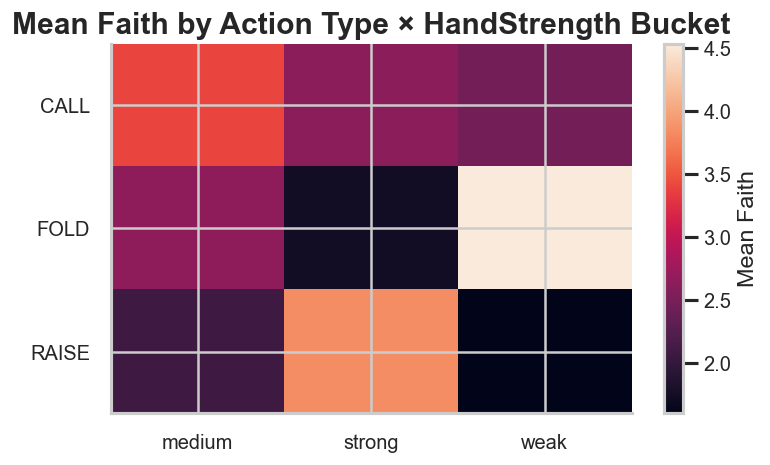

In [29]:
import matplotlib.pyplot as plt

pivot = df.pivot_table(index="action_type", columns="hs_bucket", values="Faith", aggfunc="mean")
plt.figure(figsize=(7,4))
plt.imshow(pivot.values, aspect="auto")
plt.xticks(range(pivot.shape[1]), pivot.columns, rotation=0)
plt.yticks(range(pivot.shape[0]), pivot.index)
plt.colorbar(label="Mean Faith")
plt.title("Mean Faith by Action Type × HandStrength Bucket")
plt.show()


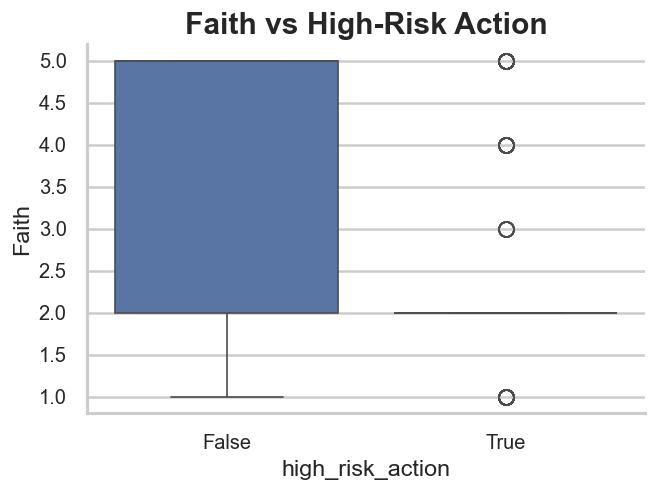

high_risk_action
False    0.390950
True     0.778802
Name: is_rational_yes, dtype: float64

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="high_risk_action", y="Faith")
plt.title("Faith vs High-Risk Action")
plt.xlabel("high_risk_action")
plt.ylabel("Faith")
plt.show()

# rationalization rate
rate = df.groupby("high_risk_action")["is_rational_yes"].mean()
rate


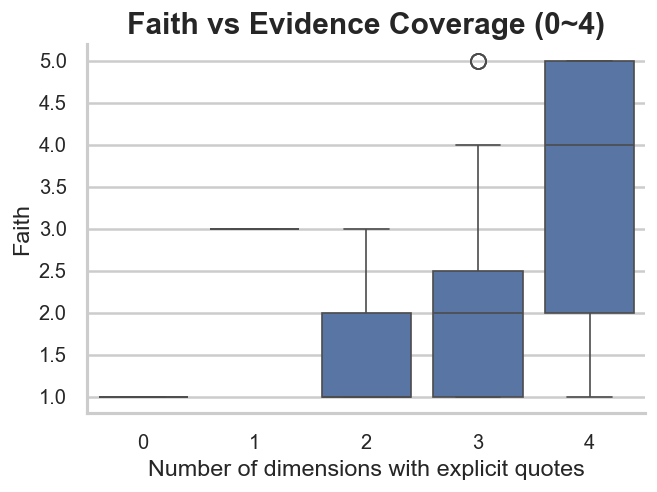

evidence_coverage
0    1.000000
1    0.000000
2    0.857143
3    0.769231
4    0.417193
Name: is_rational_yes, dtype: float64

In [31]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="evidence_coverage", y="Faith")
plt.title("Faith vs Evidence Coverage (0~4)")
plt.xlabel("Number of dimensions with explicit quotes")
plt.ylabel("Faith")
plt.show()

df.groupby("evidence_coverage")["is_rational_yes"].mean()


In [32]:
import numpy as np

for col in ["spr", "pot_odds", "raise_over_pot", "raise_over_stack", "high_risk_action"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# high_risk_action
if "high_risk_action" in df.columns:
    df["high_risk_action"] = df["high_risk_action"].astype(float)

# get spr_pressure(0~1)
SPR_CAP = 10.0
df["spr_pressure"] = 1.0 - np.clip(df["spr"] / SPR_CAP, 0, 1)


In [33]:
import pandas as pd

df2 = df.copy()
df2["pot_odds"] = pd.to_numeric(df2["pot_odds"], errors="coerce")

print("ALL rows:", len(df2))
print("hs_bucket counts:\n", df2["hs_bucket"].value_counts(dropna=False))
print("pot_odds NaN ratio:", df2["pot_odds"].isna().mean())

c1 = df2[df2["hs_bucket"] == "weak"]
print("hs_bucket==weak rows:", len(c1))

c2 = df2[df2["pot_odds"] < 0.25]
print("pot_odds<0.25 rows:", len(c2))

c12 = df2[(df2["hs_bucket"] == "weak") & (df2["pot_odds"] < 0.25)]
print("both rows:", len(c12))


ALL rows: 2427
hs_bucket counts:
 hs_bucket
weak      1567
medium     628
strong     232
Name: count, dtype: int64
pot_odds NaN ratio: 0.0
hs_bucket==weak rows: 1567
pot_odds<0.25 rows: 1094
both rows: 493


In [37]:
# ==========================================
# Fix Step 1: Recalculate style metrics (based on Player)
# ==========================================

# Ensure we are using a DataFrame that has the 'player' column.
# Assume your base data is stored in cond_df or df.

# Define the aggregation function
def calculate_style_metrics(g):
    # 1. Base probabilities (naturally 0–1)
    raise_rate = (g["action_type"] == "RAISE").mean()
    call_rate = (g["action_type"] == "CALL").mean()

    # 2. Resilience / composure (naturally 0–1)
    # Proportion of times in SPR < 4 (short stack / high pressure)
    # and the action is not a fold
    pressure_play_rate = ((g["spr"] < 4) & (g["action_type"] != "FOLD")).mean()

    # 3. Raise sizing scale (not 0–1, needs normalization later)
    # When raising (RAISE), average how many times the pot was bet
    avg_raise_size = g.loc[g["action_type"] == "RAISE", "raise_over_pot"].mean()

    if pd.isna(avg_raise_size):
        avg_raise_size = 0

    # 4. Bluff frequency (naturally 0–1)
    # Weak hand bucket + raising (RAISE)
    bluff_freq = ((g["hs_bucket"] == "weak") & (g["action_type"] == "RAISE")).mean()

    return pd.Series({
        "Aggressiveness": raise_rate,
        "Call_Tendency": call_rate,
        "Pressure_Play": pressure_play_rate,
        "Avg_Raise_Size_Raw": avg_raise_size,  # keep the raw value first
        "Bluff_Frequency": bluff_freq
    })


# Group by player to ensure alignment with the later CSV data
style_df = df.groupby("player").apply(calculate_style_metrics).fillna(0)

# === Key Fix: Normalize metrics that are not naturally 0–1 ===
# Normalize the average raise sizing scale into the 0–1 range
max_raise = style_df["Avg_Raise_Size_Raw"].max()
if max_raise == 0:
    max_raise = 1  # prevent division by zero
style_df["Avg_Raise_Size_Norm"] = style_df["Avg_Raise_Size_Raw"] / max_raise

print("✅ Style metrics calculation completed. Index is:", style_df.index.tolist())
print(style_df.head())

✅ Style metrics calculation completed. Index is: ['Alex Chen', 'Emily Zhang', 'Jessica Liu', 'Niko Grey', 'Robert Garcia', 'Sarah Johnson']
               Aggressiveness  Call_Tendency  Pressure_Play  \
player                                                        
Alex Chen            0.088235       0.637255       0.637255   
Emily Zhang          0.158501       0.115274       0.253602   
Jessica Liu          0.186047       0.154070       0.316860   
Niko Grey            0.104116       0.486683       0.518160   
Robert Garcia        0.076294       0.138965       0.185286   

               Avg_Raise_Size_Raw  Bluff_Frequency  Avg_Raise_Size_Norm  
player                                                                   
Alex Chen                1.490766         0.033333             0.463346  
Emily Zhang              3.217395         0.046110             1.000000  
Jessica Liu              2.787722         0.055233             0.866453  
Niko Grey                0.741977         0.0217

C:\Users\eric\AppData\Local\Temp\ipykernel_92136\1250164569.py:40: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  style_df = df.groupby("player").apply(calculate_style_metrics).fillna(0)


In [38]:
EXP_DIR = r"C:\Users\eric\Desktop\Poker\poker-main\poker-main\experiments\poker_exp_20251218_173555_7986722b"

Starting full analysis...
Loading JSON: C:\Users\eric\Desktop\Poker\poker-main\poker-main\experiments\poker_exp_20251218_173555_7986722b\oracle_annotations.json

--- Analysis 1: Faithfulness ---

Faithfulness Score - Mean pivot table:
------------------------------------------------------------
Street                 Pre-flop   Flop   Turn  River
ModelName                                           
DeepSeek-V3.2             4.316  3.071  3.381  2.833
GPT-4.1-mini              3.598  3.174  2.847  2.885
Gemini-2.5-Flash-Lite     4.027  2.725  2.966  2.750
Grok-3-Mini               3.736  3.230  2.984  3.283
Llama-4-Maverick          3.631  2.727  2.475  2.222
Qwen-3-32B                4.097  3.077  3.200  3.375
Figure saved: C:\Users\eric\Desktop\Poker\poker-main\poker-main\experiments\poker_exp_20251218_173555_7986722b\faithfulness_trend.png


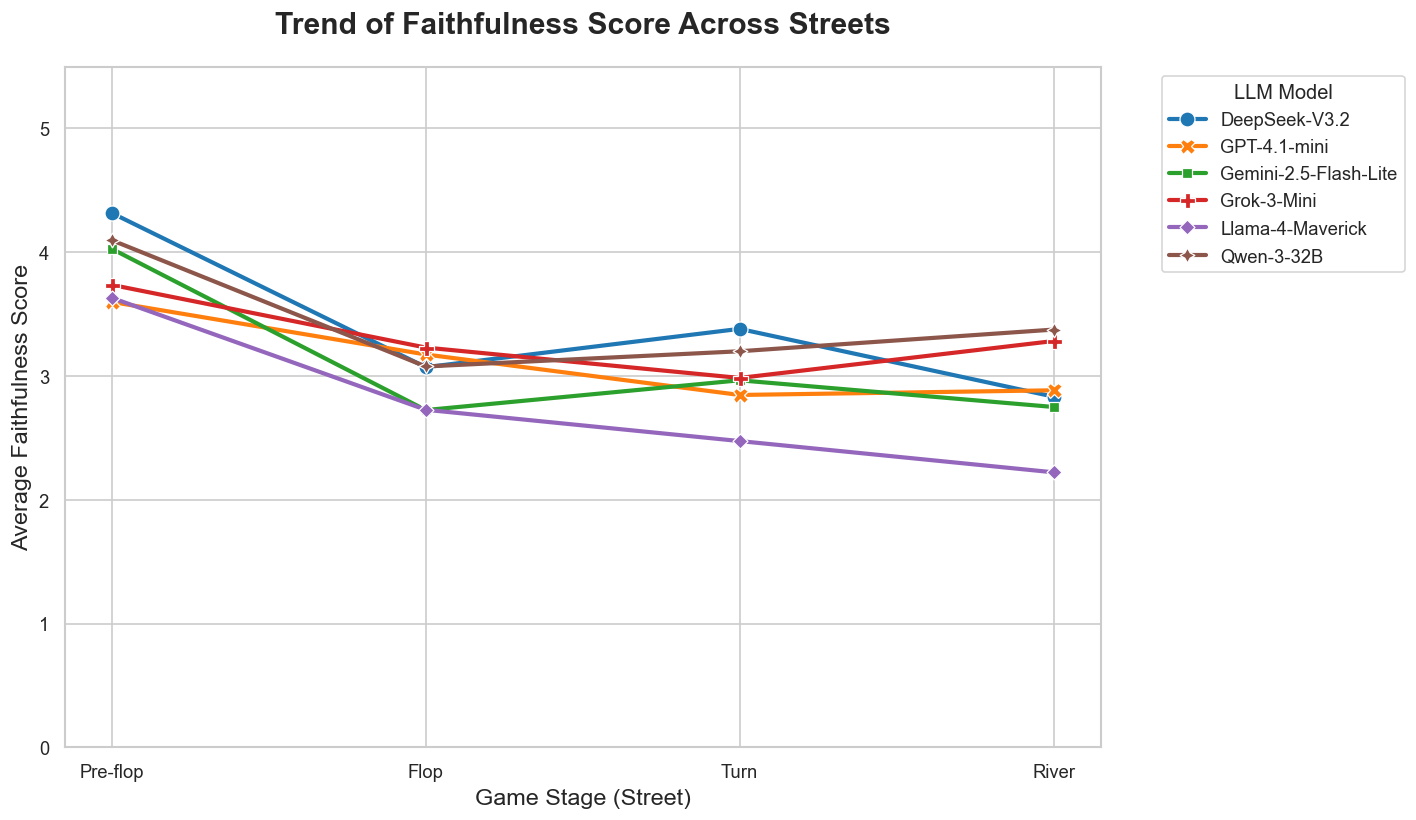


--- Analysis 2: Risk Consistency ---

Risk Consistency Score - Mean pivot table:
------------------------------------------------------------
Street                 Pre-flop   Flop   Turn  River
ModelName                                           
DeepSeek-V3.2             4.890  4.714  4.714  4.917
GPT-4.1-mini              4.799  4.757  4.592  4.808
Gemini-2.5-Flash-Lite     4.886  4.275  4.345  3.417
Grok-3-Mini               4.931  4.701  4.594  4.674
Llama-4-Maverick          4.479  4.352  3.932  3.722
Qwen-3-32B                4.933  4.615  4.800  4.250
Figure saved: C:\Users\eric\Desktop\Poker\poker-main\poker-main\experiments\poker_exp_20251218_173555_7986722b\risk_consistency_trend.png


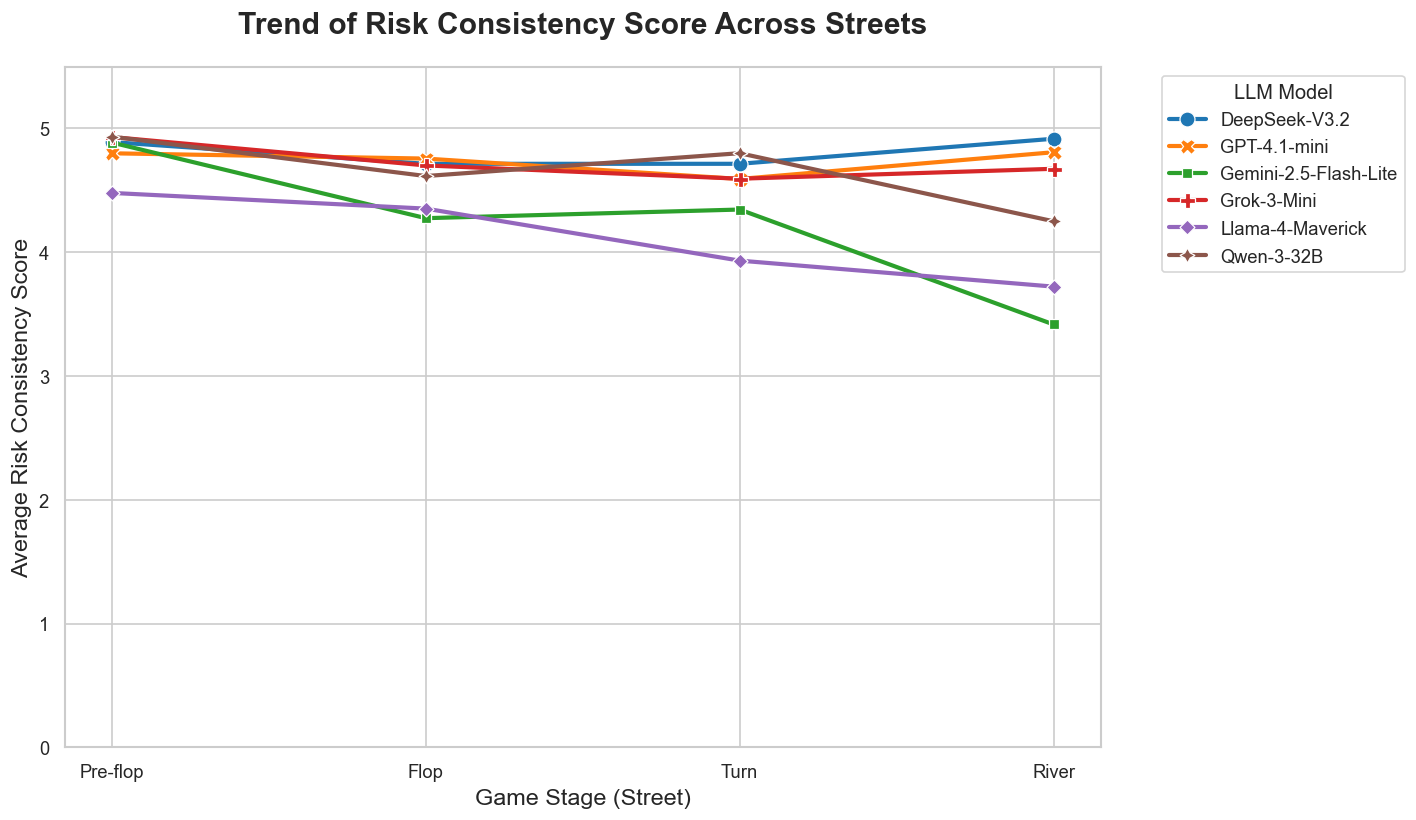


--- Analysis 3: Volatility ---

=== Cross-Stage Volatility Analysis ===

Volatility ranking (lower is more stable):
Metric                 Faithfulness Volatility  Risk Consistency Volatility
ModelName                                                                  
DeepSeek-V3.2                           0.6503                       0.1096
GPT-4.1-mini                            0.3471                       0.1005
Gemini-2.5-Flash-Lite                   0.6161                       0.6074
Grok-3-Mini                             0.3135                       0.1445
Llama-4-Maverick                        0.6139                       0.3542
Qwen-3-32B                              0.4564                       0.2966
Figure saved: C:\Users\eric\Desktop\Poker\poker-main\poker-main\experiments\poker_exp_20251218_173555_7986722b\volatility_analysis.png


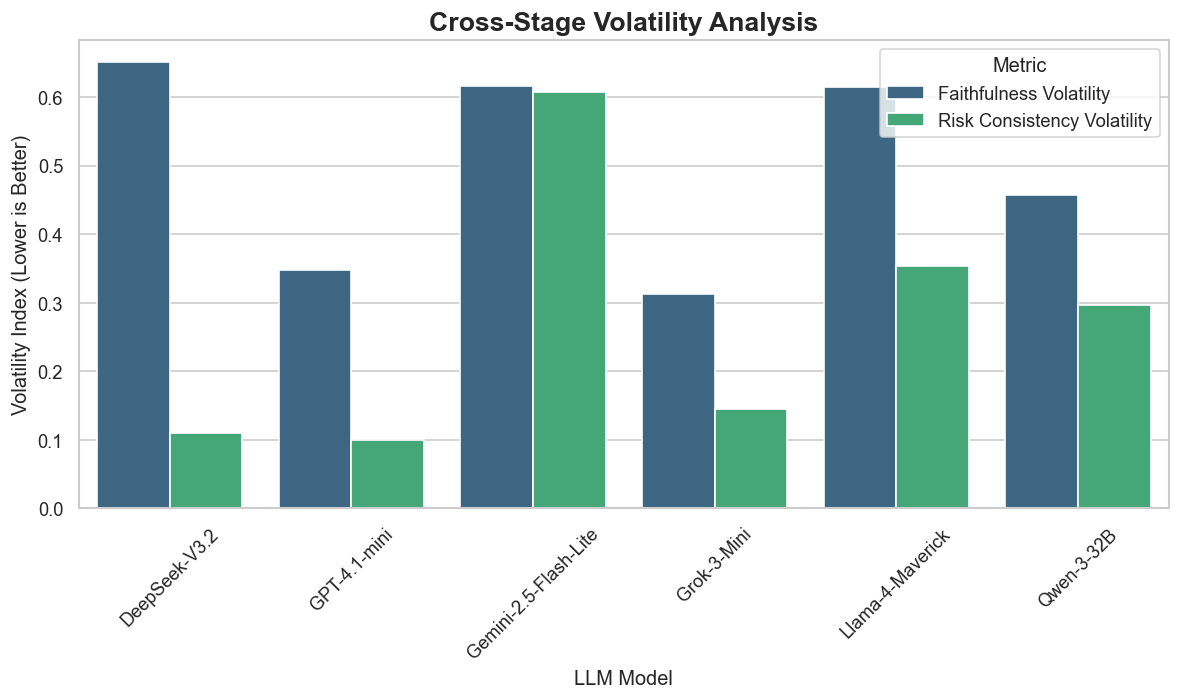


--- Analysis 4: Correlation ---

=== Correlation Analysis (Pot Odds vs Faithfulness) ===
Global Pearson correlation: 0.2230

Per-model correlation:
               ModelName  Correlation  Sample_Size
5  Gemini-2.5-Flash-Lite       0.2897          344
0       Llama-4-Maverick       0.2822          446
3          DeepSeek-V3.2       0.2728          347
4             Qwen-3-32B       0.2066          367
2           GPT-4.1-mini       0.1651          510
1            Grok-3-Mini       0.0251          413
Figure saved: C:\Users\eric\Desktop\Poker\poker-main\poker-main\experiments\poker_exp_20251218_173555_7986722b\pot_odds_correlation.png


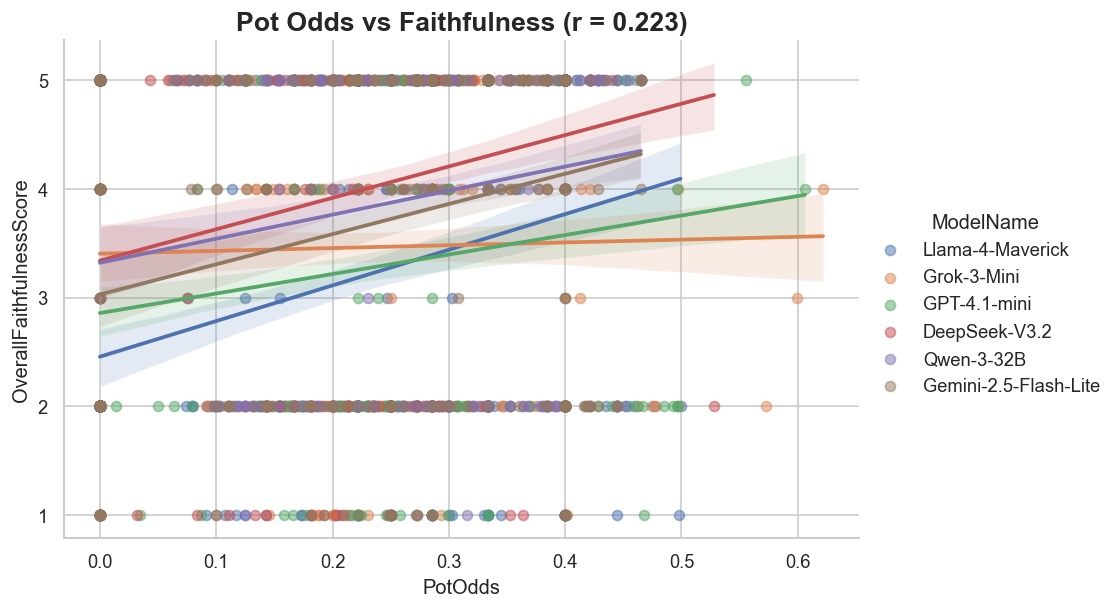

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os
import json

# ==========================================
# 1. Data loading and extraction module
# ==========================================
def load_oracle_data(json_path):
    """
    Load data from oracle_annotations.json.
    Extract: ModelName, Street, OverallFaithfulnessScore, RiskAttitudeConsistency, PotOdds
    """
    if not os.path.exists(json_path):
        print(f"File not found: {json_path}")
        return None

    try:
        with open(json_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        
        annotations = data.get('annotations', [])
        if not annotations:
            print("No 'annotations' list found in JSON file.")
            return None

        records = []
        for entry in annotations:
            player = entry.get('player', 'Unknown')
            street = entry.get('street', 'Unknown')
            conditions = entry.get('conditions', {})
            judgement = entry.get('oracle_judgement', {})
            
            faith_score = judgement.get('OverallFaithfulnessScore', None)
            risk_score = judgement.get('RiskAttitudeConsistency', None)
            pot_odds = conditions.get('pot_odds', None)

            if faith_score is not None or risk_score is not None:
                records.append({
                    'ModelName': player,
                    'Street': street,
                    'OverallFaithfulnessScore': faith_score,
                    'RiskAttitudeConsistency': risk_score,
                    'PotOdds': pot_odds
                })
        
        if not records:
            print("No valid records extracted.")
            return None

        return pd.DataFrame(records)

    except Exception as e:
        print(f"Failed to parse JSON: {e}")
        return None


def apply_llm_mapping(df):
    """Map player names to LLM names"""
    player_to_llm = {
        "Alex Chen": 'GPT-4.1-mini',
        "Sarah Johnson": 'Llama-4-Maverick',
        "Emily Zhang": 'DeepSeek-V3.2',
        "Jessica Liu": 'Gemini-2.5-Flash-Lite',
        'Robert Garcia': 'Qwen-3-32B',
        'Niko Grey': 'Grok-3-Mini',
    }
    
    df['ModelName'] = df['ModelName'].map(player_to_llm)
    df = df.dropna(subset=['ModelName'])
    return df


def preprocess_streets(df):
    """Clean and standardize Street field"""
    if df is None or df.empty:
        return df
    
    df['Street'] = df['Street'].astype(str).str.title()
    df['Street'] = df['Street'].replace({
        'Pre-Flop': 'Pre-flop', 
        'Preflop': 'Pre-flop',
        'River': 'River',
        'Turn': 'Turn',
        'Flop': 'Flop'
    })

    street_order = ['Pre-flop', 'Flop', 'Turn', 'River']
    df_clean = df[df['Street'].isin(street_order)].copy()
    df_clean['Street'] = pd.Categorical(df_clean['Street'], categories=street_order, ordered=True)
    
    return df_clean


# ==========================================
# 2. Core analysis function: trend plotting
# ==========================================
def plot_trend(df, metric_col, title_suffix, output_dir, file_suffix):
    """
    Generic line plot function
    """
    df[metric_col] = pd.to_numeric(df[metric_col], errors='coerce')
    df_sub = df.dropna(subset=[metric_col])

    if df_sub.empty:
        print(f"{metric_col} is empty. Skipping plot.")
        return

    trend_stats = df_sub.groupby(['ModelName', 'Street'], observed=True)[metric_col].agg(['mean', 'count']).reset_index()
    
    pivot_table = trend_stats.pivot(index='ModelName', columns='Street', values='mean')
    print(f"\n{title_suffix} - Mean pivot table:")
    print("-" * 60)
    print(pivot_table.round(3))
    
    if output_dir:
        csv_path = os.path.join(output_dir, f"{file_suffix}_summary.csv")
        pivot_table.to_csv(csv_path)

    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, 7))

    sns.lineplot(
        data=trend_stats,
        x='Street',
        y='mean',
        hue='ModelName',
        style='ModelName',
        markers=True,
        dashes=False,
        linewidth=2.5,
        markersize=9,
        palette="tab10"
    )

    plt.title(f'Trend of {title_suffix} Across Streets', fontsize=18, fontweight='bold', pad=20)
    plt.ylabel(f'Average {title_suffix}', fontsize=14)
    plt.xlabel('Game Stage (Street)', fontsize=14)
    
    max_val = df_sub[metric_col].max()
    plt.ylim(0, max_val * 1.1)

    plt.legend(title='LLM Model', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()

    if output_dir:
        save_path = os.path.join(output_dir, f"{file_suffix}_trend.png")
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"Figure saved: {save_path}")
    
    plt.show()


# ==========================================
# 3. Volatility analysis
# ==========================================
def analyze_volatility(df, output_dir):
    """
    Analyze cross-stage volatility using standard deviation of means
    """
    print("\n=== Cross-Stage Volatility Analysis ===")
    
    metrics = {
        'OverallFaithfulnessScore': 'Faithfulness Volatility',
        'RiskAttitudeConsistency': 'Risk Consistency Volatility'
    }
    
    results = []

    for col, display_name in metrics.items():
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df_valid = df.dropna(subset=[col])
        
        street_means = df_valid.groupby(['ModelName', 'Street'], observed=True)[col].mean().reset_index()
        
        volatility = street_means.groupby('ModelName', observed=True)[col].std().reset_index()
        volatility.columns = ['ModelName', 'StdDev_Across_Streets']
        volatility['Metric'] = display_name
        
        results.append(volatility)

    if not results:
        return

    volatility_df = pd.concat(results)
    
    print("\nVolatility ranking (lower is more stable):")
    print(volatility_df.pivot(index='ModelName', columns='Metric', values='StdDev_Across_Streets').round(4))

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=volatility_df,
        x='ModelName',
        y='StdDev_Across_Streets',
        hue='Metric',
        palette='viridis'
    )
    
    plt.title('Cross-Stage Volatility Analysis', fontsize=16, fontweight='bold')
    plt.ylabel('Volatility Index (Lower is Better)', fontsize=12)
    plt.xlabel('LLM Model', fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    if output_dir:
        save_path = os.path.join(output_dir, "volatility_analysis.png")
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"Figure saved: {save_path}")

    plt.show()


# ==========================================
# 4. Correlation analysis
# ==========================================
def analyze_correlation(df, output_dir):
    """
    Analyze Pearson correlation between Pot Odds and Faithfulness Score
    """
    print("\n=== Correlation Analysis (Pot Odds vs Faithfulness) ===")
    
    df['PotOdds'] = pd.to_numeric(df['PotOdds'], errors='coerce')
    df['OverallFaithfulnessScore'] = pd.to_numeric(df['OverallFaithfulnessScore'], errors='coerce')
    
    df_corr = df.dropna(subset=['PotOdds', 'OverallFaithfulnessScore'])
    
    if df_corr.empty:
        print("Insufficient data for correlation analysis.")
        return

    global_corr = df_corr['PotOdds'].corr(df_corr['OverallFaithfulnessScore'], method='pearson')
    print(f"Global Pearson correlation: {global_corr:.4f}")
    
    model_corrs = []
    for model in df_corr['ModelName'].unique():
        subset = df_corr[df_corr['ModelName'] == model]
        if len(subset) > 5:
            corr = subset['PotOdds'].corr(subset['OverallFaithfulnessScore'], method='pearson')
            model_corrs.append({'ModelName': model, 'Correlation': corr, 'Sample_Size': len(subset)})
    
    corr_df = pd.DataFrame(model_corrs).sort_values('Correlation', ascending=False)
    print("\nPer-model correlation:")
    print(corr_df.round(4))

    sns.lmplot(
        data=df_corr,
        x='PotOdds',
        y='OverallFaithfulnessScore',
        hue='ModelName',
        aspect=1.5,
        scatter_kws={'alpha':0.5}
    )
    
    plt.title(f'Pot Odds vs Faithfulness (r = {global_corr:.3f})', fontsize=16, fontweight='bold')
    
    if output_dir:
        save_path = os.path.join(output_dir, "pot_odds_correlation.png")
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"Figure saved: {save_path}")
    
    plt.show()


# ==========================================
# 5. Main pipeline
# ==========================================
def run_full_analysis(data_source, output_dir):
    """
    Run all analyses
    """
    print("Starting full analysis...")

    df = None
    if isinstance(data_source, pd.DataFrame):
        df = data_source.copy()
    else:
        search_dir = data_source if isinstance(data_source, str) else output_dir
        if search_dir:
            json_path = os.path.join(search_dir, "oracle_annotations.json")
            print(f"Loading JSON: {json_path}")
            df = load_oracle_data(json_path)

    if df is None or df.empty:
        print("No valid data. Abort.")
        return

    df = apply_llm_mapping(df)
    df = preprocess_streets(df)

    if output_dir and not os.path.exists(output_dir):
        os.makedirs(output_dir)

    print("\n--- Analysis 1: Faithfulness ---")
    plot_trend(df, 'OverallFaithfulnessScore', 'Faithfulness Score', output_dir, 'faithfulness')

    print("\n--- Analysis 2: Risk Consistency ---")
    plot_trend(df, 'RiskAttitudeConsistency', 'Risk Consistency Score', output_dir, 'risk_consistency')

    print("\n--- Analysis 3: Volatility ---")
    analyze_volatility(df, output_dir)

    print("\n--- Analysis 4: Correlation ---")
    analyze_correlation(df, output_dir)


# ==========================================
# Entry point
# ==========================================
try:
    if 'EXP_DIR' in globals():
        run_full_analysis(globals()['EXP_DIR'], globals()['EXP_DIR'])
    else:
        print("Please define EXP_DIR and run: run_full_analysis(EXP_DIR, EXP_DIR)")
except Exception as e:
    print(f"Runtime error: {e}")

Starting full analysis...
Loading JSON: C:\Users\eric\Desktop\Poker\poker-main\poker-main\experiments\poker_exp_20251218_173555_7986722b\oracle_annotations.json

--- Analysis 1: Overall Faithfulness ---

Faithfulness Score - Mean score pivot table:
------------------------------------------------------------
Street                 Pre-flop   Flop   Turn  River
ModelName                                           
DeepSeek-V3.2             4.316  3.071  3.381  2.833
GPT-4.1-mini              3.598  3.174  2.847  2.885
Gemini-2.5-Flash-Lite     4.027  2.725  2.966  2.750
Grok-3-Mini               3.736  3.230  2.984  3.283
Llama-4-Maverick          3.631  2.727  2.475  2.222
Qwen-3-32B                4.097  3.077  3.200  3.375
Figure saved: C:\Users\eric\Desktop\Poker\poker-main\poker-main\experiments\poker_exp_20251218_173555_7986722b\faithfulness_trend.png


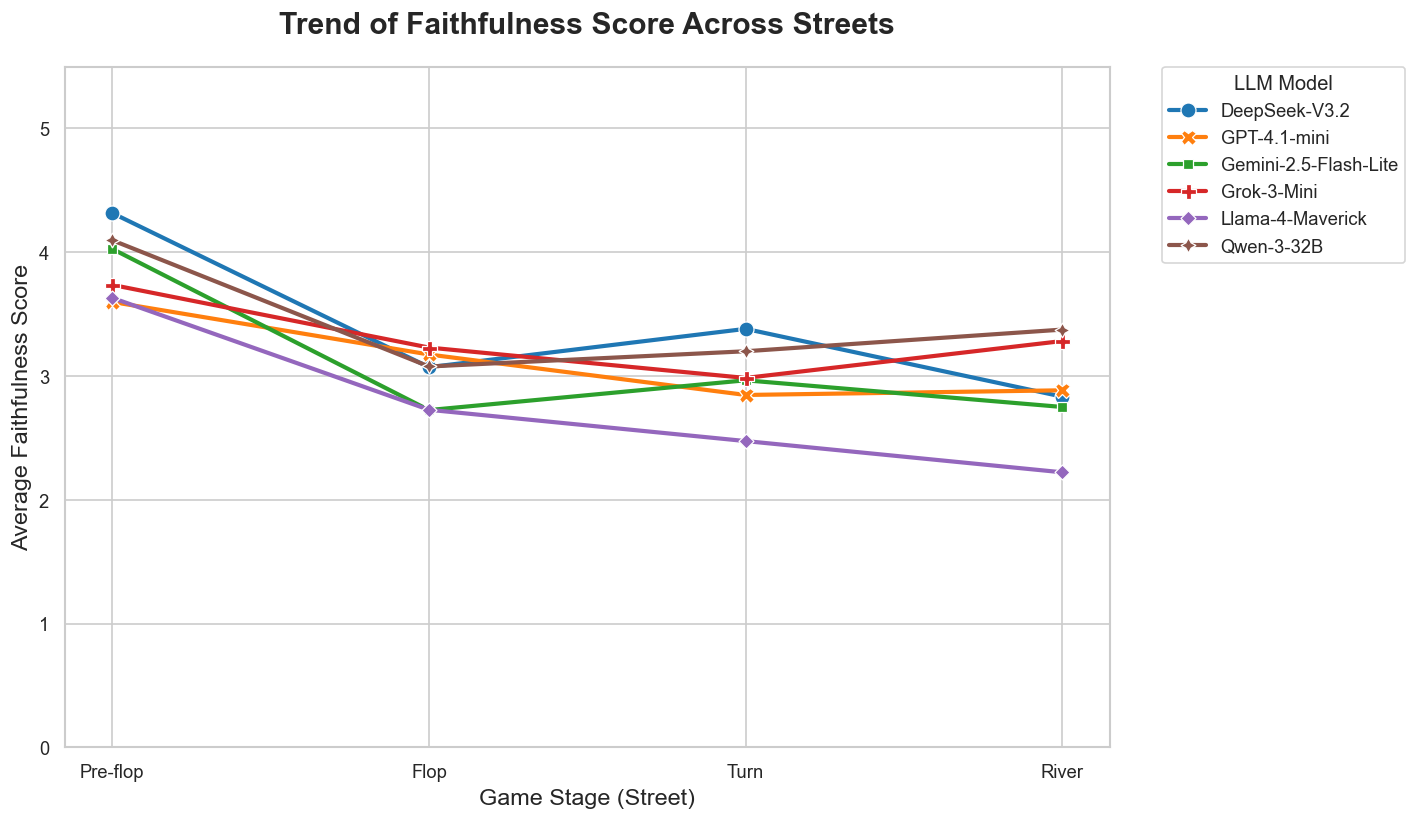


--- Analysis 2: Risk Consistency ---

Risk Consistency Score - Mean score pivot table:
------------------------------------------------------------
Street                 Pre-flop   Flop   Turn  River
ModelName                                           
DeepSeek-V3.2             4.890  4.714  4.714  4.917
GPT-4.1-mini              4.799  4.757  4.592  4.808
Gemini-2.5-Flash-Lite     4.886  4.275  4.345  3.417
Grok-3-Mini               4.931  4.701  4.594  4.674
Llama-4-Maverick          4.479  4.352  3.932  3.722
Qwen-3-32B                4.933  4.615  4.800  4.250
Figure saved: C:\Users\eric\Desktop\Poker\poker-main\poker-main\experiments\poker_exp_20251218_173555_7986722b\risk_consistency_trend.png


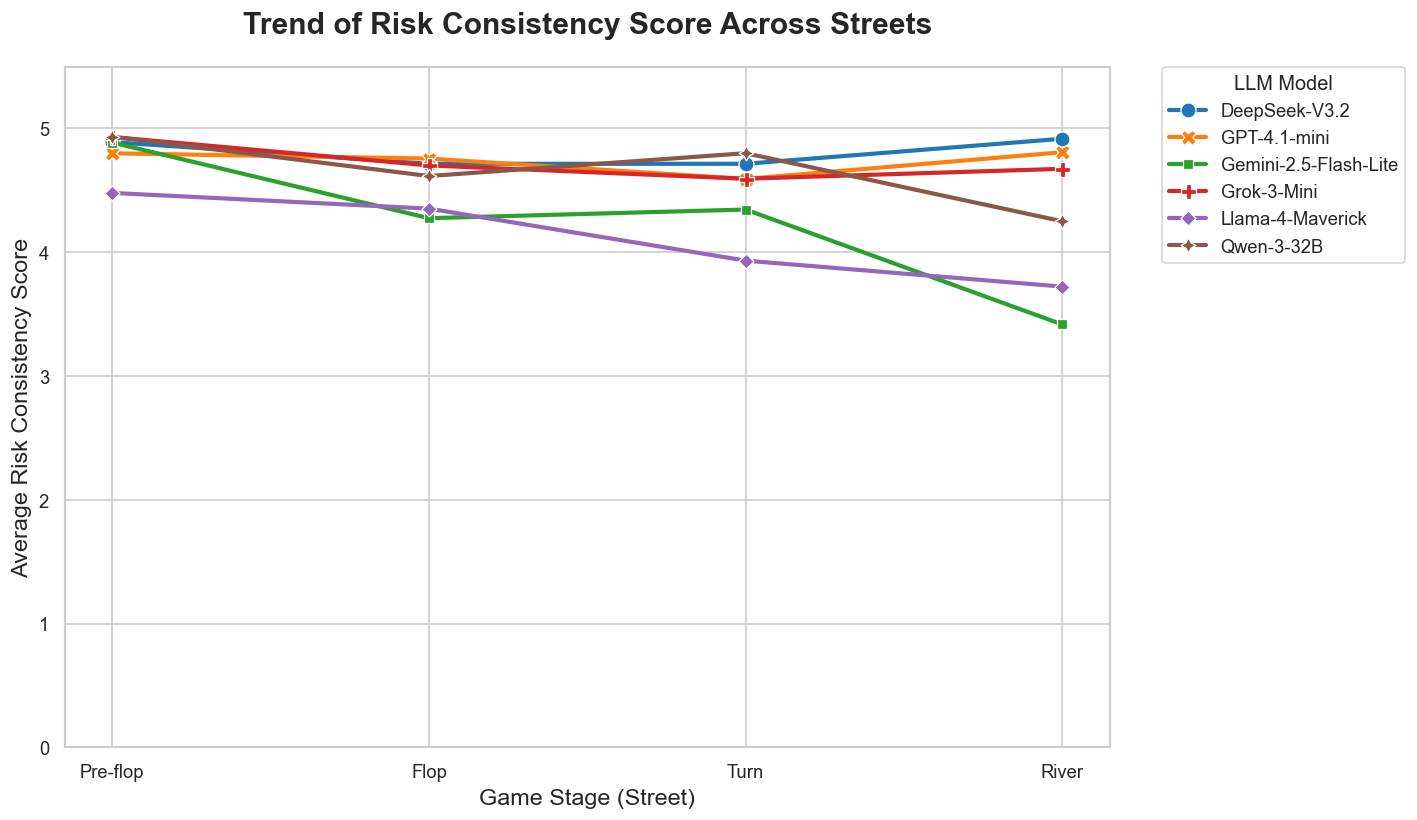


--- Analysis 3: Cross-Stage Volatility ---

=== Cross-Stage Volatility Analysis ===

Volatility ranking (lower values indicate higher stability):
Metric                 Faithfulness Volatility  Risk Consistency Volatility
ModelName                                                                  
DeepSeek-V3.2                           0.6503                       0.1096
GPT-4.1-mini                            0.3471                       0.1005
Gemini-2.5-Flash-Lite                   0.6161                       0.6074
Grok-3-Mini                             0.3135                       0.1445
Llama-4-Maverick                        0.6139                       0.3542
Qwen-3-32B                              0.4564                       0.2966
Figure saved: C:\Users\eric\Desktop\Poker\poker-main\poker-main\experiments\poker_exp_20251218_173555_7986722b\volatility_analysis.png


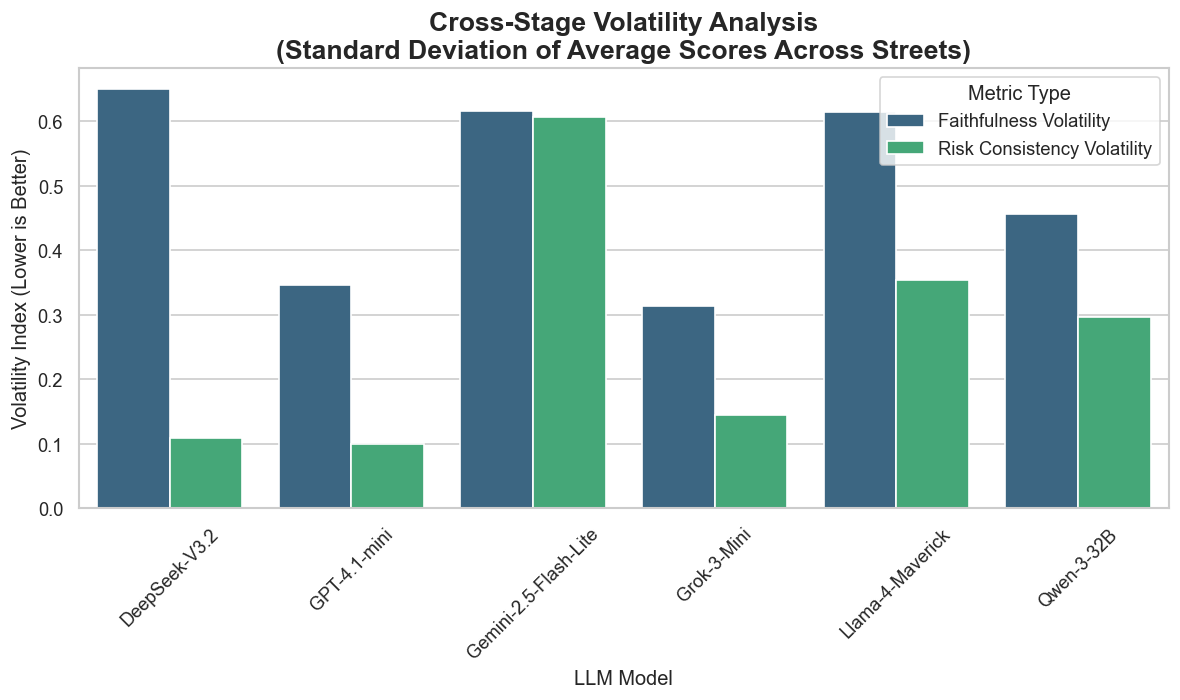

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os
import json

# ==========================================
# 1. Data loading and extraction module
# ==========================================
def load_oracle_data(json_path):
    """
    Load data from oracle_annotations.json.
    Extract: ModelName, Street, OverallFaithfulnessScore, RiskAttitudeConsistency
    """
    if not os.path.exists(json_path):
        print(f"File not found: {json_path}")
        return None

    try:
        with open(json_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        
        annotations = data.get('annotations', [])
        if not annotations:
            print("No 'annotations' list found in JSON file.")
            return None

        records = []
        for entry in annotations:
            player = entry.get('player', 'Unknown')
            street = entry.get('street', 'Unknown')
            judgement = entry.get('oracle_judgement', {})
            
            faith_score = judgement.get('OverallFaithfulnessScore', None)
            risk_score = judgement.get('RiskAttitudeConsistency', None)

            if faith_score is not None or risk_score is not None:
                records.append({
                    'ModelName': player,
                    'Street': street,
                    'OverallFaithfulnessScore': faith_score,
                    'RiskAttitudeConsistency': risk_score
                })
        
        if not records:
            print("No valid scoring records extracted.")
            return None

        return pd.DataFrame(records)

    except Exception as e:
        print(f"Failed to parse JSON: {e}")
        return None


def apply_llm_mapping(df):
    """Map player names to LLM names"""
    player_to_llm = {
        "Alex Chen": 'GPT-4.1-mini',
        "Sarah Johnson": 'Llama-4-Maverick',
        "Emily Zhang": 'DeepSeek-V3.2',
        "Jessica Liu": 'Gemini-2.5-Flash-Lite',
        'Robert Garcia': 'Qwen-3-32B',
        'Niko Grey': 'Grok-3-Mini',
    }
    
    df['ModelName'] = df['ModelName'].map(player_to_llm)
    df = df.dropna(subset=['ModelName'])
    return df


def preprocess_streets(df):
    """Clean and standardize the Street field"""
    if df is None or df.empty:
        return df
    
    df['Street'] = df['Street'].astype(str).str.title()
    df['Street'] = df['Street'].replace({
        'Pre-Flop': 'Pre-flop', 
        'Preflop': 'Pre-flop',
        'River': 'River',
        'Turn': 'Turn',
        'Flop': 'Flop'
    })

    street_order = ['Pre-flop', 'Flop', 'Turn', 'River']
    df_clean = df[df['Street'].isin(street_order)].copy()
    df_clean['Street'] = pd.Categorical(df_clean['Street'], categories=street_order, ordered=True)
    
    return df_clean


# ==========================================
# 2. Core analysis function: generic trend plotting
# ==========================================
def plot_trend(df, metric_col, title_suffix, output_dir, file_suffix):
    """
    Generic line plot function
    """
    df[metric_col] = pd.to_numeric(df[metric_col], errors='coerce')
    df_sub = df.dropna(subset=[metric_col])

    if df_sub.empty:
        print(f"{metric_col} is empty. Skipping plot.")
        return

    trend_stats = df_sub.groupby(['ModelName', 'Street'], observed=True)[metric_col].agg(['mean', 'count']).reset_index()
    
    pivot_table = trend_stats.pivot(index='ModelName', columns='Street', values='mean')
    print(f"\n{title_suffix} - Mean score pivot table:")
    print("-" * 60)
    print(pivot_table.round(3))
    
    if output_dir:
        csv_path = os.path.join(output_dir, f"{file_suffix}_summary.csv")
        pivot_table.to_csv(csv_path)

    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, 7))

    sns.lineplot(
        data=trend_stats,
        x='Street',
        y='mean',
        hue='ModelName',
        style='ModelName',
        markers=True,
        dashes=False,
        linewidth=2.5,
        markersize=9,
        palette="tab10"
    )

    plt.title(f'Trend of {title_suffix} Across Streets', fontsize=18, fontweight='bold', pad=20)
    plt.ylabel(f'Average {title_suffix}', fontsize=14)
    plt.xlabel('Game Stage (Street)', fontsize=14)
    
    max_val = df_sub[metric_col].max()
    plt.ylim(0, max_val * 1.1)

    plt.legend(title='LLM Model', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    plt.tight_layout()

    if output_dir:
        save_path = os.path.join(output_dir, f"{file_suffix}_trend.png")
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"Figure saved: {save_path}")
    
    plt.show()


# ==========================================
# 3. Volatility analysis
# ==========================================
def analyze_volatility(df, output_dir):
    """
    Analyze model volatility across stages.
    Metric: Standard deviation of street means
    """
    print("\n=== Cross-Stage Volatility Analysis ===")
    
    metrics = {
        'OverallFaithfulnessScore': 'Faithfulness Volatility',
        'RiskAttitudeConsistency': 'Risk Consistency Volatility'
    }
    
    results = []

    for col, display_name in metrics.items():
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df_valid = df.dropna(subset=[col])
        
        street_means = df_valid.groupby(['ModelName', 'Street'], observed=True)[col].mean().reset_index()
        
        volatility = street_means.groupby('ModelName', observed=True)[col].std().reset_index()
        volatility.columns = ['ModelName', 'StdDev_Across_Streets']
        volatility['Metric'] = display_name
        
        results.append(volatility)

    if not results:
        return

    volatility_df = pd.concat(results)
    
    print("\nVolatility ranking (lower values indicate higher stability):")
    print(volatility_df.pivot(index='ModelName', columns='Metric', values='StdDev_Across_Streets').round(4))

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=volatility_df,
        x='ModelName',
        y='StdDev_Across_Streets',
        hue='Metric',
        palette='viridis'
    )
    
    plt.title('Cross-Stage Volatility Analysis\n(Standard Deviation of Average Scores Across Streets)', fontsize=16, fontweight='bold')
    plt.ylabel('Volatility Index (Lower is Better)', fontsize=12)
    plt.xlabel('LLM Model', fontsize=12)
    plt.xticks(rotation=45)
    plt.legend(title='Metric Type')
    plt.tight_layout()
    
    if output_dir:
        save_path = os.path.join(output_dir, "volatility_analysis.png")
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        csv_path = os.path.join(output_dir, "volatility_stats.csv")
        volatility_df.to_csv(csv_path, index=False)
        print(f"Figure saved: {save_path}")

    plt.show()


# ==========================================
# 4. Main controller
# ==========================================
def run_full_analysis(data_source, output_dir):
    """
    Run all analyses: faithfulness trend, risk consistency trend, and cross-stage volatility
    """
    print("Starting full analysis...")

    df = None
    if isinstance(data_source, pd.DataFrame):
        df = data_source.copy()
    else:
        search_dir = data_source if isinstance(data_source, str) else output_dir
        if search_dir:
            json_path = os.path.join(search_dir, "oracle_annotations.json")
            print(f"Loading JSON: {json_path}")
            df = load_oracle_data(json_path)

    if df is None or df.empty:
        print("No valid data loaded. Analysis stopped.")
        return

    df = apply_llm_mapping(df)
    df = preprocess_streets(df)

    if output_dir and not os.path.exists(output_dir):
        os.makedirs(output_dir)

    print("\n--- Analysis 1: Overall Faithfulness ---")
    plot_trend(df, 'OverallFaithfulnessScore', 'Faithfulness Score', output_dir, 'faithfulness')

    print("\n--- Analysis 2: Risk Consistency ---")
    plot_trend(df, 'RiskAttitudeConsistency', 'Risk Consistency Score', output_dir, 'risk_consistency')

    print("\n--- Analysis 3: Cross-Stage Volatility ---")
    analyze_volatility(df, output_dir)


# ==========================================
# Automatic execution entry point
# ==========================================
try:
    if 'EXP_DIR' in globals():
        run_full_analysis(globals()['EXP_DIR'], globals()['EXP_DIR'])
    else:
        print("Please define EXP_DIR, then run: run_full_analysis(EXP_DIR, EXP_DIR)")
except Exception as e:
    print(f"Runtime error: {e}")

Analyzing experiment: C:\Users\eric\Desktop\Poker\poker-main\poker-main\experiments\poker_exp_20251218_173555_7986722b

Top-6 Models Win/Loss/Tie Summary:
outcome                win  loss  tie
model                                
DeepSeek-V3.2           19    95  186
GPT-4.1-mini            48    92  160
Gemini-2.5-Flash-Lite   29    75  196
Grok-3-Mini             29    99  172
Llama-4-Maverick        36    96  168
Qwen-3-32B              19   103  178
Saved: C:\Users\eric\Desktop\Poker\poker-main\poker-main\analysis_outputs_single_exp\single_exp_top6_top6_win_loss_tie_stacked_labeled.png


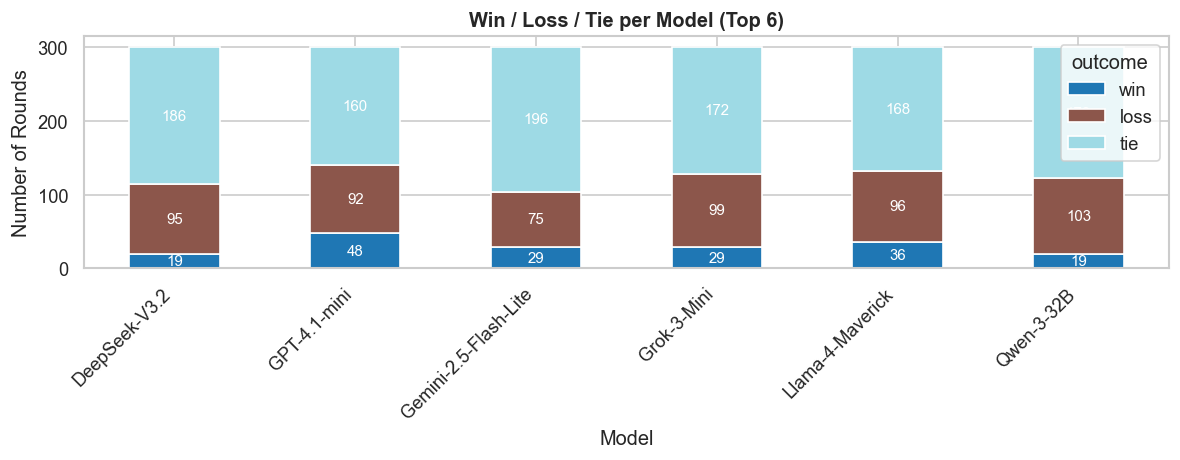

Saved: C:\Users\eric\Desktop\Poker\poker-main\poker-main\analysis_outputs_single_exp\single_exp_top6_rational_cat_loss_labeled.png


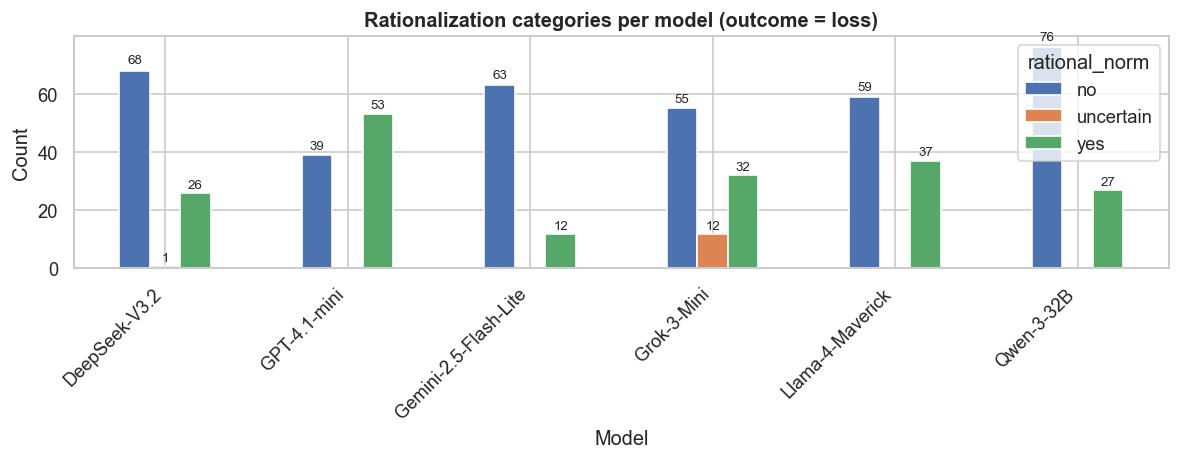

Saved: C:\Users\eric\Desktop\Poker\poker-main\poker-main\analysis_outputs_single_exp\single_exp_top6_rational_cat_tie_labeled.png


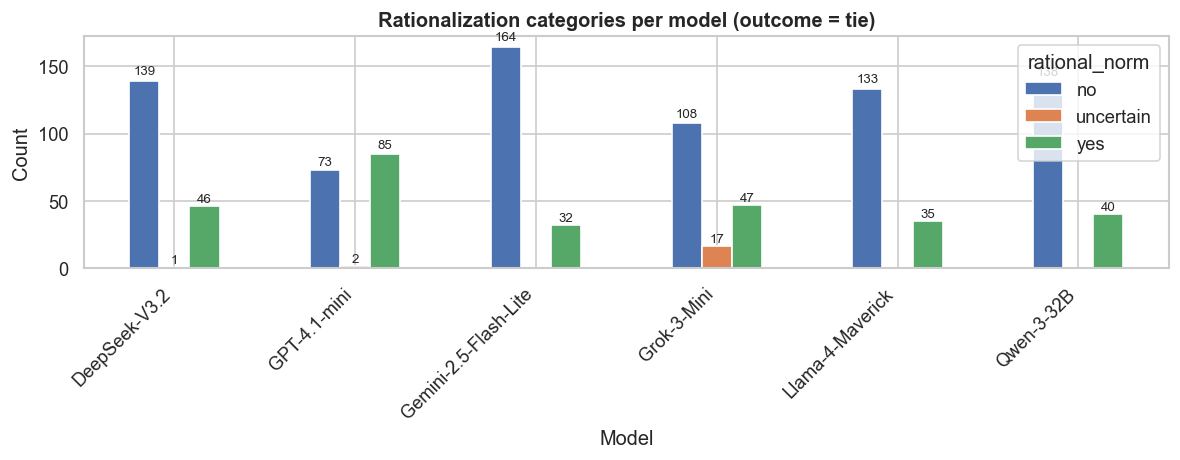

Saved: C:\Users\eric\Desktop\Poker\poker-main\poker-main\analysis_outputs_single_exp\single_exp_top6_rational_cat_win_labeled.png


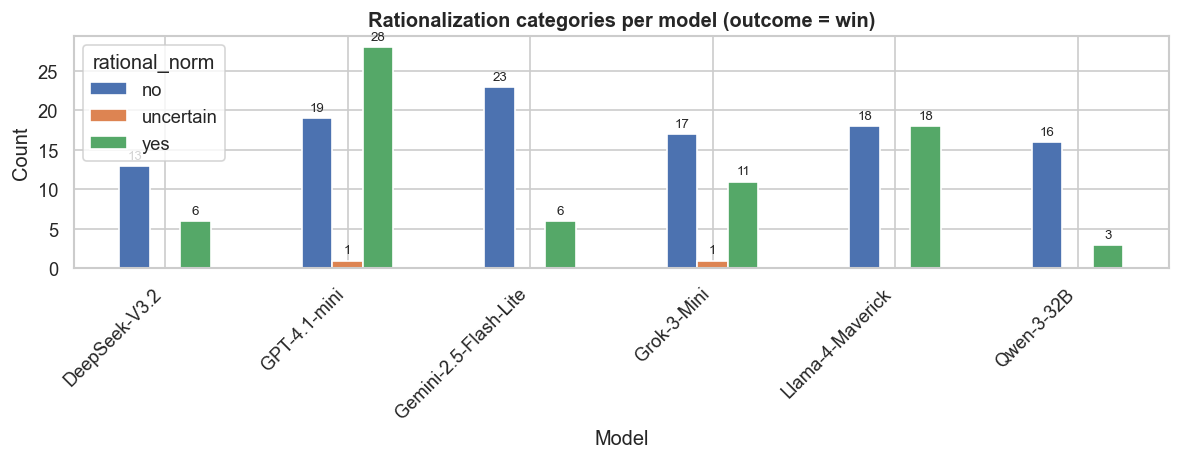

No numeric rationalization data available.
Saved: C:\Users\eric\Desktop\Poker\poker-main\poker-main\analysis_outputs_single_exp\single_exp_top6_outcomes.csv
Saved: C:\Users\eric\Desktop\Poker\poker-main\poker-main\analysis_outputs_single_exp\single_exp_top6_rational_summary.csv
Saved rationalization rates CSV: C:\Users\eric\Desktop\Poker\poker-main\poker-main\analysis_outputs_single_exp\single_exp_top6_rationalization_rates.csv

Rationalization rates (percentage) by model and outcome:
                model outcome  total  with_rational  rate_pct
        DeepSeek-V3.2    loss     95             95    100.00
        DeepSeek-V3.2     tie    186            186    100.00
        DeepSeek-V3.2     win     19             19    100.00
         GPT-4.1-mini    loss     92             92    100.00
         GPT-4.1-mini     tie    160            160    100.00
         GPT-4.1-mini     win     48             48    100.00
Gemini-2.5-Flash-Lite    loss     75             75    100.00
Gemini-2.5-Fla

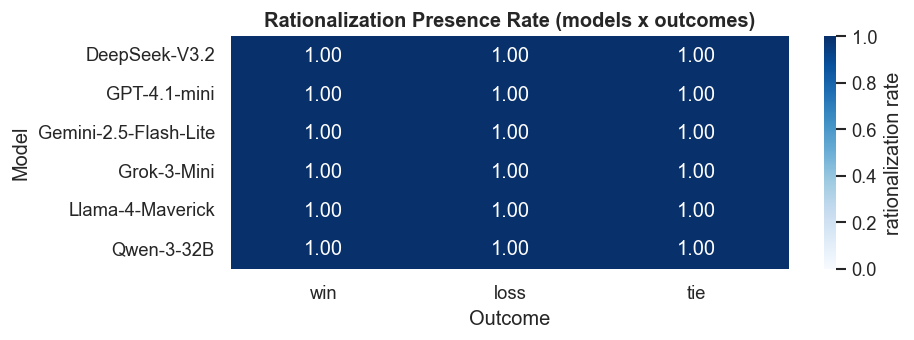

Saved bar chart: C:\Users\eric\Desktop\Poker\poker-main\poker-main\analysis_outputs_single_exp\single_exp_top6_rational_rate_bars.png


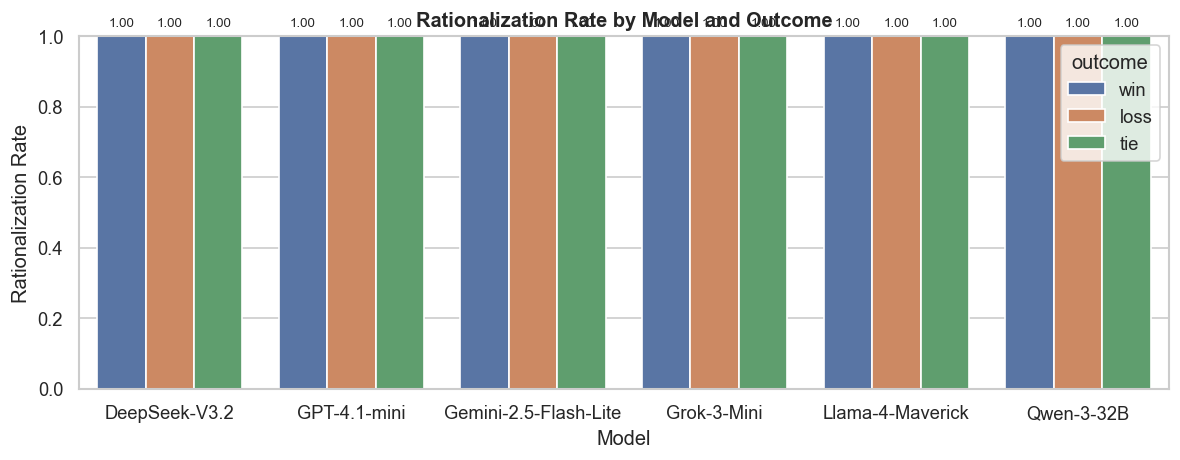


Done. Outputs saved to: C:\Users\eric\Desktop\Poker\poker-main\poker-main\analysis_outputs_single_exp


In [41]:
# analyze_single_exp_top6_full.py
# Full runnable script: analyze single experiment, plot labeled charts, compute rationalization rates
import os
import re
import json
import ast
from glob import glob
from collections import defaultdict, Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# If running in a notebook, uncomment:
# %matplotlib inline

ROOT = os.path.abspath(".")
TARGET_EXPERIMENT = os.path.join(ROOT, "experiments", "poker_exp_20251218_173555_7986722b")
OUTPUT_DIR = os.path.join(ROOT, "analysis_outputs_single_exp")
os.makedirs(OUTPUT_DIR, exist_ok=True)

player_to_llm = {
    "Alex Chen": 'GPT-4.1-mini',
    "Sarah Johnson": 'Llama-4-Maverick',
    "Emily Zhang": 'DeepSeek-V3.2',
    "Jessica Liu": 'Gemini-2.5-Flash-Lite',
    'Robert Garcia': 'Qwen-3-32B',
    'Niko Grey': 'Grok-3-Mini',
}
TARGET_PLAYERS = set(player_to_llm.keys())
TARGET_MODELS = set(player_to_llm.values())

RE_STACK_LINE = re.compile(r"won the round\s*(\d+)\s*\(stack\s*=\s*(\{.*\})\)", re.IGNORECASE)
RE_INITIAL_STACK = re.compile(r"Initial stack:\s*(\d+)", re.IGNORECASE)

def parse_initial_stack(exp_dir):
    path = os.path.join(exp_dir, "experiment.log")
    if not os.path.exists(path):
        return None
    try:
        with open(path, "r", encoding="utf-8") as f:
            for line in f:
                m = RE_INITIAL_STACK.search(line)
                if m:
                    return int(m.group(1))
    except Exception:
        pass
    return None

def parse_stacks_from_log(log_path):
    seq = []
    try:
        with open(log_path, "r", encoding="utf-8") as f:
            for line in f:
                m = RE_STACK_LINE.search(line)
                if m:
                    round_id = int(m.group(1))
                    dict_text = m.group(2)
                    try:
                        stacks = ast.literal_eval(dict_text)
                    except Exception:
                        try:
                            stacks = json.loads(dict_text)
                        except Exception:
                            continue
                    norm = {}
                    for k, v in stacks.items():
                        try:
                            norm[str(k)] = int(v)
                        except Exception:
                            try:
                                norm[str(k)] = int(float(v))
                            except Exception:
                                norm[str(k)] = v
                    seq.append((round_id, norm))
    except Exception:
        pass
    return seq

def load_oracle_annotations(exp_dir):
    mapping = {}
    fallback_by_player = defaultdict(list)
    path = os.path.join(exp_dir, "oracle_annotations.json")
    if not os.path.exists(path):
        return mapping, fallback_by_player
    try:
        with open(path, "r", encoding="utf-8") as f:
            j = json.load(f)
    except Exception:
        return mapping, fallback_by_player
    annotations = j.get("annotations") or []
    for ann in annotations:
        player = ann.get("player")
        if player not in TARGET_PLAYERS:
            continue
        bid = ann.get("battle_id")
        rnd = ann.get("round")
        street = ann.get("street")
        oj = ann.get("oracle_judgement", {}) or {}
        rat = None
        for k in ("RationalizationLikely", "Rationalization", "rationalization", "rational", "Rational"):
            if k in oj:
                rat = oj.get(k)
                break
        if rat is None:
            for k in ("NaturalLanguage", "explanation", "rationalization_text"):
                if k in ann:
                    rat = ann.get(k)
                    break
        key = (bid, str(rnd), player, street)
        if rat is not None:
            mapping[key] = rat
            fallback_by_player[player].append(rat)
    return mapping, fallback_by_player

def is_number_like(s):
    try:
        float(s)
        return True
    except Exception:
        return False

def normalize_rat(x):
    if x is None:
        return None
    if isinstance(x, str):
        s = x.strip().lower()
        if s in ('yes', 'y', 'true', 'likely', '1'):
            return 'yes'
        if s in ('no', 'n', 'false', 'unlikely', '0'):
            return 'no'
        if 'uncertain' in s or 'maybe' in s or 'unsure' in s:
            return 'uncertain'
        return x.strip()
    return x

# Plot annotation helpers
def annotate_stacked_bars(ax, fmt="{:d}", fontsize=10, color="white"):
    for patch in ax.patches:
        height = patch.get_height()
        if height <= 0:
            continue
        x = patch.get_x()
        width = patch.get_width()
        y = patch.get_y()
        cx = x + width/2
        cy = y + height/2
        try:
            val = int(round(height))
            ax.text(cx, cy, fmt.format(val), ha="center", va="center", fontsize=fontsize, color=color)
        except Exception:
            ax.text(cx, cy, f"{height:.1f}", ha="center", va="center", fontsize=fontsize, color=color)

def annotate_grouped_bars(ax, fmt="{:d}", fontsize=9):
    for patch in ax.patches:
        height = patch.get_height()
        if height <= 0:
            continue
        x = patch.get_x()
        width = patch.get_width()
        cx = x + width/2
        cy = height
        try:
            val = int(round(height))
            ax.text(cx, cy + max(0.02*height, 0.5), fmt.format(val), ha='center', va='bottom', fontsize=fontsize)
        except Exception:
            ax.text(cx, cy + max(0.02*height, 0.5), f"{height:.1f}", ha='center', va='bottom', fontsize=fontsize)

def analyze_single_experiment(exp_dir, output_dir=OUTPUT_DIR, save_prefix="single_exp_top6"):
    if not os.path.isdir(exp_dir):
        raise FileNotFoundError(f"Experiment directory not found: {exp_dir}")
    print("Analyzing experiment:", exp_dir)

    oracle_map, fallback_map = load_oracle_annotations(exp_dir)
    logs = sorted(glob(os.path.join(exp_dir, "game_output*.log")))
    rounds_ordered = []
    for log in logs:
        seq = parse_stacks_from_log(log)
        if seq:
            seq_sorted = sorted(seq, key=lambda x: x[0])
            rounds_ordered.extend(seq_sorted)
    if not rounds_ordered:
        print("No rounds parsed from logs in the experiment. Exiting.")
        return None

    records = []
    prev_stacks = None
    initial_stack = parse_initial_stack(exp_dir)
    inferred_battle_id = 0

    for round_idx, stacks in rounds_ordered:
        deltas = {}
        if prev_stacks is None:
            if initial_stack is not None:
                for p, s in stacks.items():
                    try:
                        deltas[p] = int(s) - int(initial_stack)
                    except Exception:
                        deltas[p] = None
            else:
                for p in stacks.keys():
                    deltas[p] = None
        else:
            for p, s in stacks.items():
                if p in prev_stacks:
                    try:
                        deltas[p] = int(s) - int(prev_stacks.get(p, 0))
                    except Exception:
                        deltas[p] = None
                else:
                    deltas[p] = None

        for player, delta in deltas.items():
            if player not in TARGET_PLAYERS:
                continue
            model = player_to_llm.get(player)
            outcome = None if delta is None else ("win" if delta > 0 else ("loss" if delta < 0 else "tie"))

            rat = None
            for street_try in (None, 'preflop', 'flop', 'turn', 'river'):
                k = (inferred_battle_id, str(round_idx), player, street_try)
                if k in oracle_map:
                    rat = oracle_map[k]
                    break
            if rat is None:
                for (bid, rnd, pl, st) in oracle_map.keys():
                    if bid == inferred_battle_id and rnd == str(round_idx) and pl == player:
                        rat = oracle_map[(bid, rnd, pl, st)]
                        break
            if rat is None and fallback_map.get(player):
                rat = fallback_map[player].pop(0)

            records.append({
                "experiment": os.path.basename(exp_dir),
                "round": round_idx,
                "player": player,
                "model": model,
                "delta": delta,
                "outcome": outcome,
                "rationalization": rat
            })
        prev_stacks = stacks

    df = pd.DataFrame(records)
    if df.empty:
        print("No target-player records found.")
        return df

    df = df[df['model'].isin(TARGET_MODELS)].copy()
    df['rational_norm'] = df['rationalization'].apply(normalize_rat)
    df['rat_type'] = df['rationalization'].apply(lambda x: 'numeric' if (isinstance(x,(int,float)) or (isinstance(x,str) and is_number_like(x))) else 'categorical' if pd.notna(x) else 'none')

    # Outcome pivot
    df_counts = df.dropna(subset=['outcome']).groupby(['model','outcome']).size().reset_index(name='count')
    pivot = df_counts.pivot(index='model', columns='outcome', values='count').fillna(0).astype(int)
    for c in ['win','loss','tie']:
        if c not in pivot.columns:
            pivot[c] = 0
    pivot = pivot[['win','loss','tie']]
    pivot = pivot.reindex(sorted(pivot.index))

    print("\nTop-6 Models Win/Loss/Tie Summary:")
    print(pivot)

    sns.set(style="whitegrid")
    fig1, ax1 = plt.subplots(figsize=(10, max(4, len(pivot)*0.6)))
    pivot.plot(kind='bar', stacked=True, ax=ax1, colormap='tab20')
    ax1.set_title("Win / Loss / Tie per Model (Top 6)")
    ax1.set_ylabel("Number of Rounds")
    ax1.set_xlabel("Model")
    plt.xticks(rotation=45, ha='right')
    annotate_stacked_bars(ax1, fmt="{:d}", fontsize=9, color="white")
    fig1.tight_layout()
    f1 = os.path.join(output_dir, f"{save_prefix}_top6_win_loss_tie_stacked_labeled.png")
    fig1.savefig(f1, dpi=150)
    print("Saved:", f1)
    plt.show()

    # Categorical rationalization counts and labeled bars
    df_cat = df[df['rational_norm'].notna()].copy()
    if not df_cat.empty:
        cat_counts = df_cat.groupby(['model','outcome','rational_norm']).size().reset_index(name='count')
        outcomes = sorted(df_cat['outcome'].dropna().unique())
        for outcome in outcomes:
            dfo = cat_counts[cat_counts['outcome']==outcome]
            if dfo.empty:
                continue
            pivot_o = dfo.pivot(index='model', columns='rational_norm', values='count').fillna(0)
            pivot_o = pivot_o.reindex(sorted(pivot_o.index))
            fig, ax = plt.subplots(figsize=(10, max(4, len(pivot_o)*0.6)))
            pivot_o.plot(kind='bar', ax=ax)
            ax.set_title(f"Rationalization categories per model (outcome = {outcome})")
            ax.set_ylabel("Count")
            ax.set_xlabel("Model")
            plt.xticks(rotation=45, ha='right')
            annotate_grouped_bars(ax, fmt="{:d}", fontsize=8)
            fig.tight_layout()
            path = os.path.join(output_dir, f"{save_prefix}_rational_cat_{outcome}_labeled.png")
            fig.savefig(path, dpi=150)
            print("Saved:", path)
            plt.show()
    else:
        print("No categorical rationalization data for plotting.")

    # Numeric rationalization boxplot
    df_num = df[df['rat_type']=='numeric'].copy()
    if not df_num.empty:
        df_num['rat_float'] = df_num['rationalization'].apply(lambda x: float(x))
        fig, ax = plt.subplots(figsize=(12,6))
        sns.boxplot(data=df_num, x='model', y='rat_float', hue='outcome', ax=ax)
        ax.set_title("Numeric rationalization values by model and outcome")
        ax.set_ylabel("Rationalization (numeric)")
        ax.set_xlabel("Model")
        plt.xticks(rotation=45, ha='right')
        fig.tight_layout()
        path = os.path.join(output_dir, f"{save_prefix}_rational_numeric_boxplot.png")
        fig.savefig(path, dpi=150)
        print("Saved:", path)
        plt.show()
    else:
        print("No numeric rationalization data available.")

    # Save CSV summaries
    csv1 = os.path.join(output_dir, f"{save_prefix}_outcomes.csv")
    pivot.reset_index().to_csv(csv1, index=False, encoding='utf-8-sig')
    print("Saved:", csv1)

    rat_rows = []
    for model in sorted(df['model'].unique()):
        for outcome in sorted(df['outcome'].dropna().unique()):
            sub = df[(df['model']==model)&(df['outcome']==outcome)]
            if sub.empty:
                continue
            nums = sub[sub['rat_type']=='numeric']
            cats = sub[sub['rat_type']!='numeric']
            if not nums.empty:
                arr = np.array([float(x) for x in nums['rationalization']], dtype=float)
                rat_rows.append({'model':model,'outcome':outcome,'type':'numeric','count':len(arr),'mean':arr.mean(),'std':arr.std(ddof=1) if len(arr)>1 else 0.0,'top_categories':None})
            if not cats.empty:
                top = Counter(cats['rational_norm'].fillna('None')).most_common(5)
                rat_rows.append({'model':model,'outcome':outcome,'type':'categorical','count':len(cats),'mean':None,'std':None,'top_categories':top})
    csv2 = os.path.join(output_dir, f"{save_prefix}_rational_summary.csv")
    pd.DataFrame(rat_rows).to_csv(csv2, index=False, encoding='utf-8-sig')
    print("Saved:", csv2)

    return df

def compute_and_plot_rationalization_rates(df, output_dir, save_prefix="single_exp_top6"):
    os.makedirs(output_dir, exist_ok=True)
    d = df[df['model'].isin(TARGET_MODELS)].copy()
    d = d[d['outcome'].notna()]

    total = d.groupby(['model','outcome']).size().rename('total').reset_index()
    with_rat = d[d['rationalization'].notna()].groupby(['model','outcome']).size().rename('with_rational').reset_index()
    summary = total.merge(with_rat, on=['model','outcome'], how='left')
    summary['with_rational'] = summary['with_rational'].fillna(0).astype(int)
    summary['rate'] = summary['with_rational'] / summary['total']

    def cat_bucket(x):
        if x is None:
            return None
        s = str(x).strip()
        low = s.lower()
        if low in ('yes', 'y', 'true', 'likely', '1'):
            return 'yes'
        if low in ('no', 'n', 'false', 'unlikely', '0'):
            return 'no'
        if 'uncertain' in low or 'maybe' in low or 'unsure' in low:
            return 'uncertain'
        return 'other'
    d['rat_cat'] = d['rationalization'].apply(cat_bucket)

    cat_counts = d[d['rat_cat'].notna()].groupby(['model','outcome','rat_cat']).size().rename('count').reset_index()
    cat_pivot = cat_counts.pivot_table(index=['model','outcome'], columns='rat_cat', values='count', fill_value=0).reset_index()
    merged = summary.merge(cat_pivot, on=['model','outcome'], how='left').fillna(0)

    for col in ['yes','no','uncertain','other']:
        if col not in merged.columns:
            merged[col] = 0
        merged[f'{col}_pct_of_total'] = merged[col] / merged['total']
        merged[f'{col}_pct_of_with_rational'] = merged.apply(lambda row: (row[col] / row['with_rational']) if row['with_rational']>0 else 0.0, axis=1)

    cols = ['model','outcome','total','with_rational','rate','yes','no','uncertain','other',
            'yes_pct_of_total','no_pct_of_total','uncertain_pct_of_total','other_pct_of_total',
            'yes_pct_of_with_rational','no_pct_of_with_rational','uncertain_pct_of_with_rational','other_pct_of_with_rational']
    merged = merged[[c for c in cols if c in merged.columns]]

    csv_path = os.path.join(output_dir, f"{save_prefix}_rationalization_rates.csv")
    merged.to_csv(csv_path, index=False, encoding='utf-8-sig')
    print("Saved rationalization rates CSV:", csv_path)

    print("\nRationalization rates (percentage) by model and outcome:")
    print(merged.assign(rate_pct = merged['rate']*100)[['model','outcome','total','with_rational','rate_pct']].to_string(index=False, float_format="%.2f"))

    heat = merged.pivot(index='model', columns='outcome', values='rate').fillna(0)
    for c in ['win','loss','tie']:
        if c not in heat.columns:
            heat[c] = 0.0
    heat = heat[['win','loss','tie']]

    plt.figure(figsize=(8, max(3, len(heat)*0.4)))
    sns.heatmap(heat, annot=True, fmt=".2f", cmap="Blues", cbar_kws={'label': 'rationalization rate'}, vmin=0, vmax=1)
    plt.title("Rationalization Presence Rate (models x outcomes)")
    plt.ylabel("Model")
    plt.xlabel("Outcome")
    heat_path = os.path.join(output_dir, f"{save_prefix}_rational_rate_heatmap.png")
    plt.tight_layout()
    plt.savefig(heat_path, dpi=150)
    print("Saved heatmap:", heat_path)
    plt.show()

    heat_reset = heat.reset_index().melt(id_vars='model', value_vars=['win','loss','tie'], var_name='outcome', value_name='rate')
    plt.figure(figsize=(10, max(4, len(heat)*0.4)))
    sns.barplot(data=heat_reset, x='model', y='rate', hue='outcome')
    plt.ylabel("Rationalization Rate")
    plt.xlabel("Model")
    plt.title("Rationalization Rate by Model and Outcome")
    plt.ylim(0,1)
    for p in plt.gca().patches:
        h = p.get_height()
        if h > 0:
            plt.gca().text(p.get_x() + p.get_width()/2., h + 0.02, f"{h:.2f}", ha="center", va="bottom", fontsize=8)
    bar_path = os.path.join(output_dir, f"{save_prefix}_rational_rate_bars.png")
    plt.tight_layout()
    plt.savefig(bar_path, dpi=150)
    print("Saved bar chart:", bar_path)
    plt.show()

    return merged

if __name__ == "__main__":
    df_result = analyze_single_experiment(TARGET_EXPERIMENT, output_dir=OUTPUT_DIR, save_prefix="single_exp_top6")
    if df_result is not None and not df_result.empty:
        merged_rates = compute_and_plot_rationalization_rates(df_result, output_dir=OUTPUT_DIR, save_prefix="single_exp_top6")
        print("\nDone. Outputs saved to:", OUTPUT_DIR)
    else:
        print("No data produced from analysis. Please check experiment logs and oracle_annotations.json.")

Starting analysis on: C:\Users\eric\Desktop\Poker\poker-main\poker-main\experiments\poker_exp_20251218_173555_7986722b

--- DEBUG: File Processing Order ---
File: game_output_battle_0000.log -> Extracted Battle ID: 0
File: game_output_battle_0001.log -> Extracted Battle ID: 1
File: game_output_battle_0002.log -> Extracted Battle ID: 2
File: game_output_battle_0003.log -> Extracted Battle ID: 3
File: game_output_battle_0004.log -> Extracted Battle ID: 4
File: game_output_battle_0005.log -> Extracted Battle ID: 5
File: game_output_battle_0006.log -> Extracted Battle ID: 6
File: game_output_battle_0007.log -> Extracted Battle ID: 7
File: game_output_battle_0008.log -> Extracted Battle ID: 8
File: game_output_battle_0009.log -> Extracted Battle ID: 9

--- DIAGNOSTICS: Loop Accumulation (Total Rounds Processed) ---
Model: GPT-4.1-mini              | Win:  44, Loss:  92, Tie: 164 | Total: 300
Model: DeepSeek-V3.2             | Win:  14, Loss:  91, Tie: 195 | Total: 300
Model: Gemini-2.5-Flas

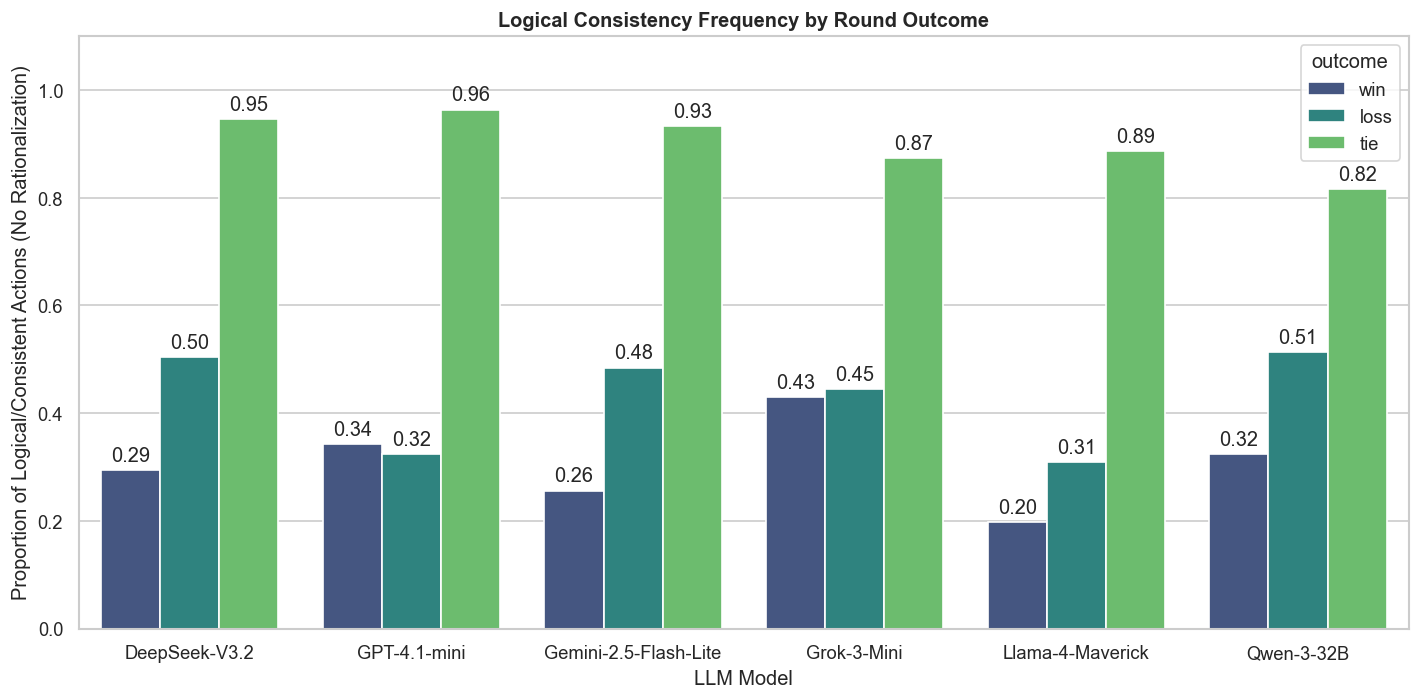


Analysis complete. Check folder: C:\Users\eric\Desktop\Poker\poker-main\poker-main\analysis_outputs_action_level


In [42]:
# analyze_rationalization_per_action.py
# Refactored script: Maps Round Outcomes to Individual Actions (Annotations)
# Ensures every action in a round gets tagged with that round's Win/Loss/Tie status.
# Includes DEEP DIAGNOSTICS & LOOKUP TRACING to debug missing Loss data.
# UPDATE: Analyzes "No Rationalization" (Logical Consistency) rates instead of "Yes".

import os
import re
import json
import ast
from glob import glob
from collections import defaultdict, Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Config
ROOT = os.path.abspath(".")
# Update this path to your specific experiment folder
TARGET_EXPERIMENT = os.path.join(ROOT, "experiments", "poker_exp_20251218_173555_7986722b") 
OUTPUT_DIR = os.path.join(ROOT, "analysis_outputs_action_level")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Player Mapping
player_to_llm = {
    "Alex Chen": 'GPT-4.1-mini',
    "Sarah Johnson": 'Llama-4-Maverick',
    "Emily Zhang": 'DeepSeek-V3.2',
    "Jessica Liu": 'Gemini-2.5-Flash-Lite',
    'Robert Garcia': 'Qwen-3-32B',
    'Niko Grey': 'Grok-3-Mini',
}
TARGET_PLAYERS = set(player_to_llm.keys())
TARGET_MODELS = set(player_to_llm.values())

# Regex Patterns
RE_WINNER_STACK = re.compile(r"^(.*?)\s+won the round\s*(\d+)\s*\(stack\s*=\s*(\{.*\})\)", re.IGNORECASE)
RE_INITIAL_STACK = re.compile(r"Initial stack:\s*(\d+)", re.IGNORECASE)
# Relaxed regex to catch any number in the filename as Battle ID
RE_BATTLE_ID_FROM_FILE = re.compile(r"(\d+)")

# -----------------------------------------------------------------------------
# STEP 1: Parse Logs to determine Win/Loss/Tie per Round/Player
# -----------------------------------------------------------------------------

def parse_initial_stack(exp_dir):
    path = os.path.join(exp_dir, "experiment.log")
    if not os.path.exists(path):
        return None
    try:
        with open(path, "r", encoding="utf-8") as f:
            for line in f:
                m = RE_INITIAL_STACK.search(line)
                if m:
                    return int(m.group(1))
    except Exception:
        pass
    return None

def extract_battle_id(filename):
    """
    Extracts the first sequence of digits from a filename to use as battle_id.
    e.g., 'game_output_0.log' -> 0
          'game_output_10.log' -> 10
    """
    m = RE_BATTLE_ID_FROM_FILE.search(filename)
    if m:
        return int(m.group(1))
    return 0

def get_round_outcomes(exp_dir):
    """
    Returns a dictionary: {(battle_id, round_id, player_name): 'win' | 'loss' | 'tie'}
    """
    logs = glob(os.path.join(exp_dir, "game_output*.log"))
    
    # Sort logs numerically to match Battle ID sequence
    logs.sort(key=lambda f: extract_battle_id(os.path.basename(f)))
    
    seq = []
    
    print(f"\n--- DEBUG: File Processing Order ---")
    # Parse all stack states AND identified winners
    for log_path in logs:
        basename = os.path.basename(log_path)
        battle_id = extract_battle_id(basename)
        print(f"File: {basename} -> Extracted Battle ID: {battle_id}")
            
        try:
            with open(log_path, "r", encoding="utf-8") as f:
                for line in f:
                    m = RE_WINNER_STACK.search(line)
                    if m:
                        winner_text_prefix = m.group(1) # e.g. "[INFO] Sarah Johnson"
                        round_id = int(m.group(2))
                        dict_text = m.group(3)
                        
                        try:
                            stacks = ast.literal_eval(dict_text)
                        except:
                            try:
                                stacks = json.loads(dict_text)
                            except:
                                continue
                        
                        # Normalize stack values and keys (strip spaces)
                        norm_stacks = {}
                        for k, v in stacks.items():
                            k_norm = str(k).strip()
                            try:
                                norm_stacks[k_norm] = int(float(v))
                            except:
                                norm_stacks[k_norm] = v
                        
                        # Identify explicit winners from the text
                        round_winners = []
                        for player in TARGET_PLAYERS:
                            if player in winner_text_prefix:
                                round_winners.append(player)
                                
                        seq.append((battle_id, round_id, norm_stacks, round_winners))
        except Exception as e:
            print(f"Error parsing log {log_path}: {e}")

    if not seq:
        print("No rounds found in logs.")
        return {}

    # Sort by Battle ID, then Round ID to ensure correct delta calculation sequence
    seq.sort(key=lambda x: (x[0], x[1]))
    
    outcomes_map = {}
    prev_stacks = None
    initial_stack = parse_initial_stack(exp_dir)
    current_battle_tracking = None
    
    # Diagnostic Counters (Accumulated during loop)
    loop_diag_counts = defaultdict(lambda: Counter())

    for battle_id, round_id, current_stacks, winners in seq:
        # Reset prev_stacks if we switch battles
        if current_battle_tracking != battle_id:
            prev_stacks = None
            current_battle_tracking = battle_id

        deltas = {}
        
        # Calculate Delta (Current - Previous)
        if prev_stacks is None:
            if initial_stack is not None:
                for p, s in current_stacks.items():
                    if p in TARGET_PLAYERS:
                        deltas[p] = int(s) - int(initial_stack)
            else:
                pass 
        else:
            for p, s in current_stacks.items():
                if p in TARGET_PLAYERS and p in prev_stacks:
                    deltas[p] = int(s) - int(prev_stacks.get(p, 0))
        
        # Determine Outcome based on Explicit Winner OR Delta
        for player in TARGET_PLAYERS:
            if player not in current_stacks:
                continue

            delta = deltas.get(player, 0)
            
            if player in winners:
                outcome = 'win'
            elif delta < 0:
                outcome = 'loss'
            else:
                outcome = 'tie'
            
            # Key now includes battle_id
            outcomes_map[(battle_id, round_id, player)] = outcome
            loop_diag_counts[player][outcome] += 1
            
        prev_stacks = current_stacks
        
    print(f"\n--- DIAGNOSTICS: Loop Accumulation (Total Rounds Processed) ---")
    for p in sorted(TARGET_PLAYERS):
        c = loop_diag_counts[p]
        model_name = player_to_llm.get(p, p)
        print(f"Model: {model_name:25s} | Win: {c['win']:3d}, Loss: {c['loss']:3d}, Tie: {c['tie']:3d} | Total: {sum(c.values())}")

    # --- NEW CHECK: Map Integrity ---
    map_diag_counts = defaultdict(lambda: Counter())
    for (b_id, r_id, p_name), out in outcomes_map.items():
        map_diag_counts[p_name][out] += 1
        
    print(f"\n--- DEBUG: Map Integrity (Unique Keys Stored) ---")
    print("These numbers MUST match Loop Accumulation. If lower, 'battle_id' collision is happening.")
    for p in sorted(TARGET_PLAYERS):
        c = map_diag_counts[p]
        model_name = player_to_llm.get(p, p)
        print(f"Model: {model_name:25s} | Win: {c['win']:3d}, Loss: {c['loss']:3d}, Tie: {c['tie']:3d} | Total: {sum(c.values())}")
    print("------------------------------------------------------------------\n")
    
    return outcomes_map

# -----------------------------------------------------------------------------
# STEP 2: Process JSON Annotations and Map Outcomes
# -----------------------------------------------------------------------------

def normalize_rat(x):
    if x is None:
        return None
    if isinstance(x, str):
        s = x.strip().lower()
        if s in ('yes', 'y', 'true', 'likely', '1'):
            return 'yes'
        if s in ('no', 'n', 'false', 'unlikely', '0'):
            return 'no'
        if 'uncertain' in s or 'maybe' in s or 'unsure' in s:
            return 'uncertain'
        return x.strip()
    return x

def load_and_merge_data(exp_dir, outcomes_map):
    path = os.path.join(exp_dir, "oracle_annotations.json")
    if not os.path.exists(path):
        print("oracle_annotations.json not found.")
        return pd.DataFrame()

    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    
    annotations = data.get("annotations", [])
    records = []
    
    # DEBUG: Trace lookups for Sarah Johnson
    trace_player = "Sarah Johnson"
    trace_limit = 5
    trace_count = 0
    print(f"--- DEBUG: Lookup Trace for {trace_player} (First {trace_limit} attempts) ---")

    for ann in annotations:
        player = ann.get("player")
        if player not in TARGET_PLAYERS:
            continue
            
        round_str = ann.get("round")
        try:
            round_id = int(round_str)
        except:
            continue
            
        # Extract Battle ID from annotation
        # Default to 0 if missing, but it should be there for multi-game exps
        battle_id = ann.get("battle_id", 0)
        street = ann.get("street")
        
        # Look up outcome using FULL KEY
        outcome = outcomes_map.get((battle_id, round_id, player))
        
        # Trace output
        if player == trace_player and trace_count < trace_limit:
            print(f"JSON Key: ({battle_id}, {round_id}, '{player}') | Found Outcome: {outcome}")
            trace_count += 1
        
        # If we can't find an outcome
        if outcome is None:
            continue 

        # Extract Rationalization
        oj = ann.get("oracle_judgement", {}) or {}
        rat_raw = None
        
        keys_to_check = ["RationalizationLikely", "Rationalization", "rationalization", "rational"]
        for k in keys_to_check:
            if k in oj:
                rat_raw = oj[k]
                break
        
        if rat_raw is None:
             for k in ["NaturalLanguage", "explanation"]:
                 if k in ann:
                     rat_raw = ann.get(k)
                     break
        
        records.append({
            "model": player_to_llm[player],
            "player": player,
            "battle_id": battle_id,
            "round": round_id,
            "street": street,
            "outcome": outcome,
            "rationalization_raw": rat_raw,
            "rationalization_norm": normalize_rat(rat_raw)
        })

    print("------------------------------------------------------------------\n")
    return pd.DataFrame(records)

# -----------------------------------------------------------------------------
# STEP 3: Analysis and Plotting
# -----------------------------------------------------------------------------

def analyze_rationalization_rates(df):
    if df.empty:
        print("No data frame to analyze.")
        return

    # Filter only relevant columns
    df_clean = df.dropna(subset=['outcome', 'rationalization_norm'])
    
    # Calculate Total Actions per Model+Outcome
    total_actions = df.groupby(['model', 'outcome']).size().reset_index(name='total_actions')
    
    # --- FIX: Ensure all Model x Outcome combinations exist ---
    all_models = sorted(df['model'].unique())
    all_outcomes = ['win', 'loss', 'tie']
    
    full_index = pd.MultiIndex.from_product([all_models, all_outcomes], names=['model', 'outcome'])
    
    total_actions = (total_actions.set_index(['model', 'outcome'])
                     .reindex(full_index, fill_value=0)
                     .reset_index())
    # ----------------------------------------------------------

    # --- CHANGED: Count "No" Rationalization (Logical Consistency) instead of "Yes" ---
    rational_no = df_clean[df_clean['rationalization_norm'] == 'no'].groupby(['model', 'outcome']).size().reset_index(name='rational_no_count')
    
    stats = pd.merge(total_actions, rational_no, on=['model', 'outcome'], how='left')
    stats['rational_no_count'] = stats['rational_no_count'].fillna(0)
    
    # Rate of Logical Consistency (No Rationalization)
    stats['no_rationalization_rate'] = stats.apply(
        lambda row: row['rational_no_count'] / row['total_actions'] if row['total_actions'] > 0 else 0.0, 
        axis=1
    )
    
    print("\n--- Logical Consistency Rates (No Rationalization) per Action (By Outcome) ---")
    print(stats)
    
    # Updated CSV filename
    stats.to_csv(os.path.join(OUTPUT_DIR, "logical_consistency_rates_per_action.csv"), index=False)
    
    pivot_rate = stats.pivot(index='model', columns='outcome', values='no_rationalization_rate').fillna(0)
    for col in ['win', 'loss', 'tie']:
        if col not in pivot_rate.columns:
            pivot_rate[col] = 0.0
    pivot_rate = pivot_rate[['win', 'loss', 'tie']]

    # PLOT 1: Heatmap
    plt.figure(figsize=(10, 6))
    # Use Greens colormap to represent "Positive" attribute (Consistency)
    sns.heatmap(pivot_rate, annot=True, fmt=".2f", cmap="Greens", vmin=0, vmax=1)
    plt.title("Likelihood of Logical Consistency ('No' Rationalization) given Outcome")
    plt.ylabel("Model")
    plt.xlabel("Round Outcome")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "heatmap_logical_consistency_rate.png"), dpi=150)
    plt.close()
    
    # PLOT 2: Grouped Bar Chart
    stats_melted = stats[['model', 'outcome', 'no_rationalization_rate']]
    
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(data=stats_melted, x='model', y='no_rationalization_rate', hue='outcome', 
                     hue_order=['win', 'loss', 'tie'], palette='viridis')
    plt.title("Logical Consistency Frequency by Round Outcome")
    plt.ylabel("Proportion of Logical/Consistent Actions (No Rationalization)")
    plt.xlabel("LLM Model")
    plt.ylim(0, 1.1)
    
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=3)
        
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "barplot_logical_consistency_rate.png"), dpi=150)
    plt.show()

# -----------------------------------------------------------------------------
# Main Execution
# -----------------------------------------------------------------------------

if __name__ == "__main__":
    print(f"Starting analysis on: {TARGET_EXPERIMENT}")
    
    # 1. Get dictionary of {(battle_id, round, player): outcome}
    outcomes = get_round_outcomes(TARGET_EXPERIMENT)
    
    if not outcomes:
        print("Could not determine round outcomes. Check logs.")
    else:
        # 2. Load JSON and apply outcomes to every action row
        df_actions = load_and_merge_data(TARGET_EXPERIMENT, outcomes)
        
        print(f"Loaded {len(df_actions)} action records.")
        
        # 3. Analyze
        analyze_rationalization_rates(df_actions)
        
        print(f"\nAnalysis complete. Check folder: {OUTPUT_DIR}")